# Datathon 2026 — Focused EDA Notebook  
## Q9. Tồn kho có vấn đề? & Q10. Tại sao khách trả hàng?

Notebook này được dùng để thực hiện **Phần 2 — Trực quan hóa & Phân tích EDA** theo rubric 4 cấp độ:

1. **Descriptive — What happened?**: mô tả hiện trạng bằng thống kê/biểu đồ rõ ràng.  
2. **Diagnostic — Why did it happen?**: tìm nguyên nhân, phân khúc, bất thường có bằng chứng.  
3. **Predictive — What is likely to happen?**: xây chỉ số cảnh báo / xu hướng / risk score.  
4. **Prescriptive — What should we do?**: đề xuất hành động định lượng được, gắn với tác động kinh doanh.

**Dữ liệu đầu vào dùng trong notebook:**

- `merged_data/df_4.csv`: orders + shipments + reviews + returns  
- `merged_data/df_4_2.csv`: inventory + products  
- `merged_data/df_5.csv`: returns + products + order_items

In [1]:
# ============================================================
# 0. SETUP
# ============================================================

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

# Visual style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Folder logic:
# Nếu notebook nằm trong folder `datathon`, dữ liệu merged nên nằm ở `datathon/merged_data/`.
# Nếu chạy trên môi trường khác, sửa DATA_DIR/MERGED_DIR ở đây.
DATA_DIR = Path.cwd()
MERGED_DIR = DATA_DIR / "merged_data"

# Fallback cho trường hợp notebook chạy trực tiếp trong /mnt/data hoặc folder chứa file csv
if not (MERGED_DIR / "df_4.csv").exists():
    if (DATA_DIR / "df_4.csv").exists():
        MERGED_DIR = DATA_DIR
    elif Path("/mnt/data/df_4.csv").exists():
        MERGED_DIR = Path("/mnt/data")

OUTPUT_DIR = DATA_DIR / "eda_q9_q10_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print("DATA_DIR  =", DATA_DIR)
print("MERGED_DIR=", MERGED_DIR)
print("OUTPUT_DIR=", OUTPUT_DIR)

DATA_DIR  = c:\Users\Binh\Desktop\Thái An\Study\VinUniversity\Sophomore\Spring 26\Data Competition\datathon
MERGED_DIR= c:\Users\Binh\Desktop\Thái An\Study\VinUniversity\Sophomore\Spring 26\Data Competition\datathon\merged_data
OUTPUT_DIR= c:\Users\Binh\Desktop\Thái An\Study\VinUniversity\Sophomore\Spring 26\Data Competition\datathon\eda_q9_q10_outputs


In [2]:
# ============================================================
# 1. LOAD DATA
# ============================================================

df4 = pd.read_csv(MERGED_DIR / "df_4.csv", low_memory=False)
df42 = pd.read_csv(MERGED_DIR / "df_4_2.csv", low_memory=False)
df5 = pd.read_csv(MERGED_DIR / "df_5.csv", low_memory=False)

print("df4  — orders + shipments + reviews + returns:", df4.shape)
print("df42 — inventory + products:", df42.shape)
print("df5  — returns + products + order_items:", df5.shape)

display(df4.head(3))
display(df42.head(3))
display(df5.head(3))

df4  — orders + shipments + reviews + returns: (266073, 23)
df42 — inventory + products: (60247, 24)
df5  — returns + products + order_items: (307253, 20)


,order_id,order_date,customer_id_x,zip,order_status,payment_method,device_type,order_source,ship_date,delivery_date,shipping_fee,review_id,product_id_x,customer_id_y,review_date,rating,review_title,return_id,product_id_y,return_date,return_reason,return_quantity,refund_amount
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,2012-07-07,2012-07-11,1.37,REV-0000001,2400.0,58578.0,2012-07-24,5.0,Highly recommend,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search,2012-07-06,2012-07-10,2.60,NaN,NaN,NaN,NaN,NaN,NaN,RET-000001,609.0,2012-07-25,late_delivery,6.0,52458.01
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,2012-07-04,2012-07-07,2.38,REV-0000002,396.0,58811.0,2012-08-03,5.0,Very satisfied,NaN,NaN,NaN,NaN,NaN,NaN


,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name_x,category_x,segment_x,year,month,product_name_y,category_y,segment_y,size,color,price,cogs
0,2022-10-31,1,3,1,1,2,90.0,0.9333,1,0,0,0.25,DragonWear MA-01,Casual,All-weather,2022,10,DragonWear MA-01,Casual,All-weather,M,black,4945.5,2732.8833
1,2022-11-30,1,3,1,1,1,90.0,0.9667,1,0,0,0.25,DragonWear MA-01,Casual,All-weather,2022,11,DragonWear MA-01,Casual,All-weather,M,black,4945.5,2732.8833
2,2022-12-31,1,3,1,1,1,90.0,0.9667,1,0,0,0.25,DragonWear MA-01,Casual,All-weather,2022,12,DragonWear MA-01,Casual,All-weather,M,black,4945.5,2732.8833


,order_id,product_id_x,quantity,unit_price,discount_amount,promo_id,promo_id_2,product_name,category,segment,size,color,price,cogs,return_id,product_id_y,return_date,return_reason,return_quantity,refund_amount
0,1,2400,7,1138.22,0.0,NaN,NaN,VietMotion YY-09,GenZ,Trendy,S,red,1109.261061,1053.798008,NaN,NaN,NaN,NaN,NaN,NaN
1,2,609,7,10166.25,0.0,NaN,NaN,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,10426.571034,8987.704231,RET-000001,609.0,2012-07-25,late_delivery,6.0,52458.01
2,3,396,3,11220.33,0.0,NaN,NaN,SaigonFlex UM-01,Streetwear,Balanced,S,green,11028.428695,10091.012256,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# ============================================================
# 2. CLEANING & FEATURE ENGINEERING
# ============================================================

def parse_dates(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")
    return df

df4 = parse_dates(df4, ["order_date", "ship_date", "delivery_date", "review_date", "return_date"])
df42 = parse_dates(df42, ["snapshot_date"])
df5 = parse_dates(df5, ["return_date"])

# ----------------------------
# df4: logistics / experience
# ----------------------------
df4["delivery_days"] = (df4["delivery_date"] - df4["ship_date"]).dt.days
df4["order_month"] = df4["order_date"].dt.to_period("M").dt.to_timestamp()
df4["return_flag"] = df4["return_id"].notna().astype(int)
df4["review_flag"] = df4["review_id"].notna().astype(int)

# Product id in df4 can come from review side or return side
df4["product_id_any"] = df4["product_id_x"].combine_first(df4["product_id_y"])

# Delivery bucket based on observed delivery day distribution
valid_delivery = df4["delivery_days"].dropna()
p50 = valid_delivery.quantile(0.50)
p75 = valid_delivery.quantile(0.75)
p90 = valid_delivery.quantile(0.90)

def delivery_bucket(x):
    if pd.isna(x):
        return "Unknown"
    if x <= p50:
        return f"Fast (≤P50: {p50:.0f}d)"
    if x <= p75:
        return f"Normal (P50–P75)"
    if x <= p90:
        return f"Slow (P75–P90)"
    return f"Very slow (>P90: {p90:.0f}d)"

df4["delivery_bucket"] = df4["delivery_days"].apply(delivery_bucket)

# ----------------------------
# df42: inventory
# ----------------------------
# Unify product attributes from duplicated merge columns
for base_col in ["product_name", "category", "segment"]:
    x, y = f"{base_col}_x", f"{base_col}_y"
    if x in df42.columns and y in df42.columns:
        df42[base_col] = df42[x].combine_first(df42[y])
    elif x in df42.columns:
        df42[base_col] = df42[x]
    elif y in df42.columns:
        df42[base_col] = df42[y]

df42["snapshot_month"] = df42["snapshot_date"].dt.to_period("M").dt.to_timestamp()
df42["gross_margin_per_unit"] = df42["price"] - df42["cogs"]
df42["inventory_value_at_cogs"] = df42["stock_on_hand"] * df42["cogs"]

# Lost sales proxy:
# If stockout occurred, estimate unmet demand from average daily sales on in-stock days.
# This is a proxy, not actual lost revenue.
days_in_month = df42["snapshot_date"].dt.days_in_month
in_stock_days = (days_in_month - df42["stockout_days"]).clip(lower=1)
df42["avg_daily_units_sold_when_available"] = df42["units_sold"] / in_stock_days
df42["lost_units_proxy"] = np.where(
    df42["stockout_days"] > 0,
    df42["avg_daily_units_sold_when_available"] * df42["stockout_days"],
    0
)
df42["lost_revenue_proxy"] = df42["lost_units_proxy"] * df42["price"]
df42["lost_margin_proxy"] = df42["lost_units_proxy"] * df42["gross_margin_per_unit"]

# Overstock waste proxy:
# Inventory value tied in overstock SKUs.
df42["overstock_value_proxy"] = np.where(
    df42["overstock_flag"].eq(1),
    df42["inventory_value_at_cogs"],
    0
)

# Inventory risk score for next-month monitoring
df42["stockout_risk_score"] = (
    0.35 * df42["reorder_flag"].fillna(0)
    + 0.25 * df42["stockout_flag"].fillna(0)
    + 0.20 * (1 - df42["fill_rate"].fillna(df42["fill_rate"].median())).clip(0, 1)
    + 0.10 * df42["sell_through_rate"].fillna(0).clip(0, 1)
    + 0.10 * (1 / (1 + df42["days_of_supply"].fillna(df42["days_of_supply"].median()))).clip(0, 1)
)

# Lag target: whether this product stocks out next month
df42 = df42.sort_values(["product_id", "snapshot_month"])
df42["next_month_stockout_flag"] = df42.groupby("product_id")["stockout_flag"].shift(-1)

# ----------------------------
# df5: return analysis
# ----------------------------
df5["return_flag"] = df5["return_id"].notna().astype(int)
df5["net_sales"] = df5["quantity"] * df5["unit_price"] - df5["discount_amount"].fillna(0)
df5["return_quantity_clean"] = df5["return_quantity"].fillna(0)
df5["refund_amount_clean"] = df5["refund_amount"].fillna(0)

print("Done cleaning.")
print("Delivery days percentiles:", {"p50": round(p50, 2), "p75": round(p75, 2), "p90": round(p90, 2)})

Done cleaning.
Delivery days percentiles: {'p50': np.float64(4.0), 'p75': np.float64(6.0), 'p90': np.float64(7.0)}


# Q9 — Tồn kho có vấn đề không?

## Logic phân tích

Q9 không chỉ hỏi “có hết hàng hay tồn dư không”, mà cần biến nó thành câu chuyện vận hành:

- **Stockout** có thể tạo ra *hidden lost sales*: khách muốn mua nhưng không có hàng để đáp ứng.
- **Overstock** tạo ra *waste*: vốn bị giam trong hàng tồn, tăng rủi ro markdown/lỗi mốt.
- **Delivery chậm** có thể làm giảm trải nghiệm: rating thấp hơn và return cao hơn.
- Mục tiêu cuối cùng: xác định nhóm SKU/category nào cần **demand planning**, **reorder**, hoặc **markdown/liquidation**.

## Q9.1 — Descriptive: Hiện trạng stockout / overstock / lost sales proxy

,snapshot_month,sku_months,stockout_rate,overstock_rate,reorder_rate,avg_fill_rate,total_units_sold,lost_revenue_proxy,lost_margin_proxy,overstock_value_proxy,stockout_rate_pct,overstock_rate_pct,avg_fill_rate_pct
116,2022-03-01,474,0.681435,0.727848,0.0,0.962802,5096,3.233128e+06,433901.520802,4.353379e+08,68.143460,72.784810,96.280211
117,2022-04-01,496,0.701613,0.681452,0.0,0.957932,6360,2.861440e+06,578935.887854,4.561588e+08,70.161290,68.145161,95.793226
118,2022-05-01,485,0.661856,0.713402,0.0,0.964744,5509,1.491346e+06,264042.382395,4.506884e+08,66.185567,71.340206,96.474351
119,2022-06-01,464,0.674569,0.696121,0.0,0.963939,5759,2.138671e+06,322876.649627,3.961199e+08,67.456897,69.612069,96.393858
120,2022-07-01,410,0.692683,0.748780,0.0,0.964960,4123,1.201531e+06,209178.256317,3.777081e+08,69.268293,74.878049,96.496000
121,2022-08-01,461,0.652928,0.726681,0.0,0.965220,4772,1.340012e+06,216271.401495,3.904582e+08,65.292842,72.668113,96.521974
122,2022-09-01,419,0.642005,0.811456,0.0,0.966984,3360,1.024380e+06,186628.241101,4.263677e+08,64.200477,81.145585,96.698425
123,2022-10-01,409,0.655257,0.858191,0.0,0.961776,2908,1.801100e+06,298848.678624,4.034348e+08,65.525672,85.819071,96.177604
124,2022-11-01,376,0.696809,0.869681,0.0,0.959929,2332,1.038704e+06,185694.929528,3.695865e+08,69.680851,86.968085,95.992899
125,2022-12-01,424,0.672170,0.804245,0.0,0.961244,3565,1.981619e+06,456190.458113,3.828644e+08,67.216981,80.424528,96.124410


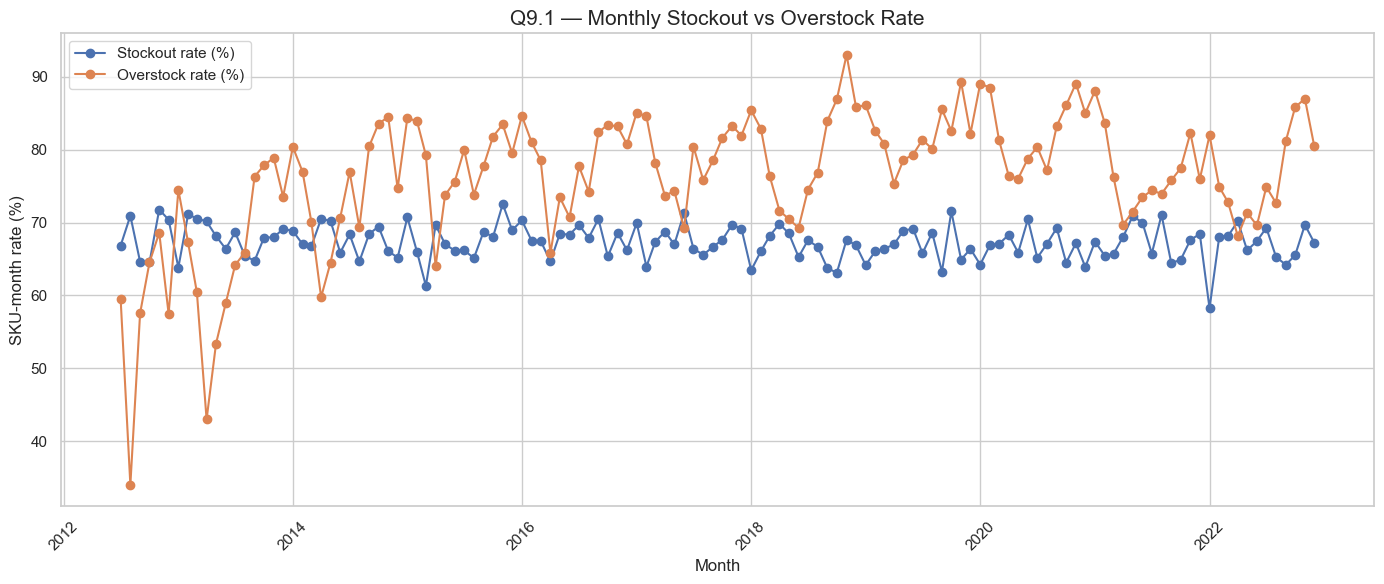

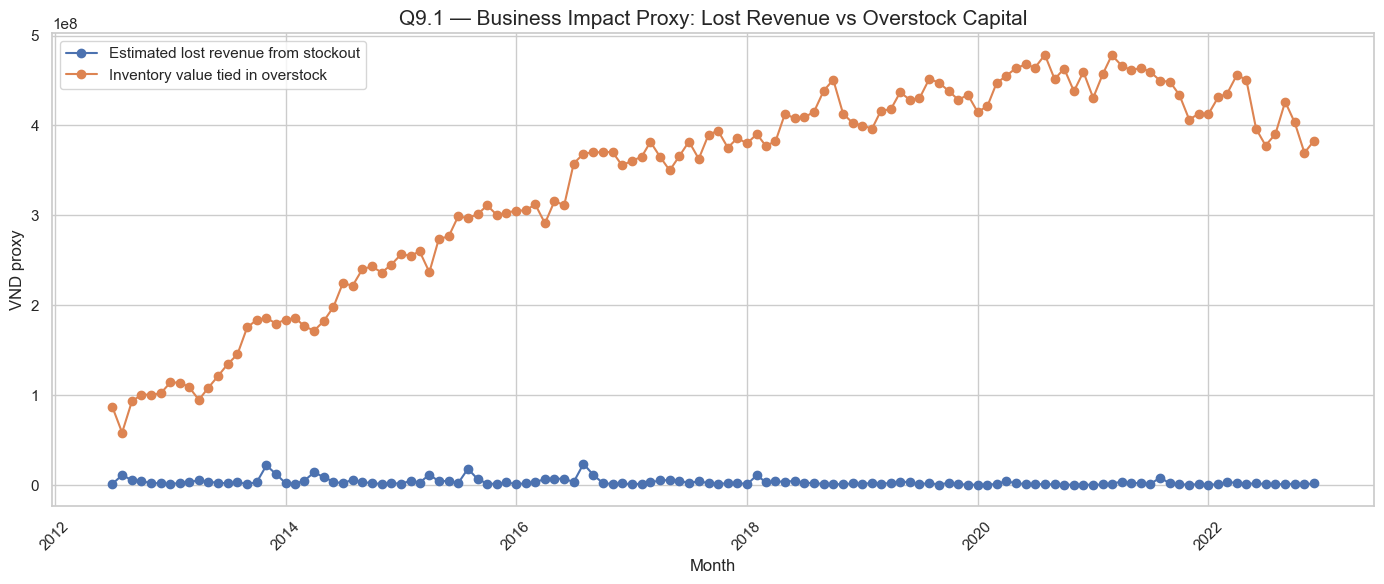

In [4]:
# ============================================================
# Q9.1 DESCRIPTIVE — Monthly inventory health
# ============================================================

monthly_inv = df42.groupby("snapshot_month").agg(
    sku_months=("product_id", "count"),
    stockout_rate=("stockout_flag", "mean"),
    overstock_rate=("overstock_flag", "mean"),
    reorder_rate=("reorder_flag", "mean"),
    avg_fill_rate=("fill_rate", "mean"),
    total_units_sold=("units_sold", "sum"),
    lost_revenue_proxy=("lost_revenue_proxy", "sum"),
    lost_margin_proxy=("lost_margin_proxy", "sum"),
    overstock_value_proxy=("overstock_value_proxy", "sum"),
).reset_index()

monthly_inv["stockout_rate_pct"] = monthly_inv["stockout_rate"] * 100
monthly_inv["overstock_rate_pct"] = monthly_inv["overstock_rate"] * 100
monthly_inv["avg_fill_rate_pct"] = monthly_inv["avg_fill_rate"] * 100

display(monthly_inv.tail(10))

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(monthly_inv["snapshot_month"], monthly_inv["stockout_rate_pct"], marker="o", label="Stockout rate (%)")
ax1.plot(monthly_inv["snapshot_month"], monthly_inv["overstock_rate_pct"], marker="o", label="Overstock rate (%)")
ax1.set_title("Q9.1 — Monthly Stockout vs Overstock Rate")
ax1.set_xlabel("Month")
ax1.set_ylabel("SKU-month rate (%)")
ax1.legend(loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_inv["snapshot_month"], monthly_inv["lost_revenue_proxy"], marker="o", label="Estimated lost revenue from stockout")
ax.plot(monthly_inv["snapshot_month"], monthly_inv["overstock_value_proxy"], marker="o", label="Inventory value tied in overstock")
ax.set_title("Q9.1 — Business Impact Proxy: Lost Revenue vs Overstock Capital")
ax.set_xlabel("Month")
ax.set_ylabel("VND proxy")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save table for report/Tableau if needed
monthly_inv.to_csv(OUTPUT_DIR / "q9_monthly_inventory_health.csv", index=False)

In [5]:
# Auto insight block for Q9.1
latest = monthly_inv.dropna().iloc[-1]
worst_stockout_month = monthly_inv.loc[monthly_inv["stockout_rate"].idxmax()]
worst_overstock_month = monthly_inv.loc[monthly_inv["overstock_rate"].idxmax()]
highest_lost_month = monthly_inv.loc[monthly_inv["lost_revenue_proxy"].idxmax()]

print("Q9.1 — DESCRIPTIVE INSIGHTS")
print(f"- Latest month: stockout rate = {latest['stockout_rate_pct']:.2f}%, overstock rate = {latest['overstock_rate_pct']:.2f}%, avg fill rate = {latest['avg_fill_rate_pct']:.2f}%.")
print(f"- Worst stockout month: {worst_stockout_month['snapshot_month'].date()} with stockout rate = {worst_stockout_month['stockout_rate_pct']:.2f}%.")
print(f"- Worst overstock month: {worst_overstock_month['snapshot_month'].date()} with overstock rate = {worst_overstock_month['overstock_rate_pct']:.2f}%.")
print(f"- Highest estimated hidden lost revenue month: {highest_lost_month['snapshot_month'].date()} with lost revenue proxy = {highest_lost_month['lost_revenue_proxy']:,.0f} VND.")

Q9.1 — DESCRIPTIVE INSIGHTS
- Latest month: stockout rate = 67.22%, overstock rate = 80.42%, avg fill rate = 96.12%.
- Worst stockout month: 2015-11-01 with stockout rate = 72.54%.
- Worst overstock month: 2018-11-01 with overstock rate = 92.99%.
- Highest estimated hidden lost revenue month: 2016-08-01 with lost revenue proxy = 23,783,631 VND.


**Cách viết vào report:**  
Biểu đồ này cho thấy tồn kho đang có hai vấn đề song song: một phần SKU bị hết hàng gây mất doanh thu tiềm ẩn, trong khi một phần SKU khác lại bị tồn dư làm giam vốn. Vì vậy, vấn đề không chỉ là “thiếu hàng” hay “dư hàng”, mà là **phân bổ tồn kho sai theo nhu cầu**.

## Q9.2 — Diagnostic: Stockout/overstock tập trung ở category/segment nào?

,category,sku_months,stockout_rate,overstock_rate,avg_fill_rate,units_sold,lost_revenue_proxy,lost_margin_proxy,overstock_value_proxy,stockout_rate_pct,overstock_rate_pct,lost_revenue_share_pct,overstock_value_share_pct
3,Streetwear,31020,0.673211,0.749259,0.960248,511467,3.492049e+08,6.039811e+07,3.255224e+10,67.321083,74.925854,78.502697,76.884048
2,Outdoor,21050,0.673492,0.798527,0.962705,337510,7.690935e+07,1.716256e+07,7.879571e+09,67.349169,79.852732,17.289539,18.610494
0,Casual,3503,0.662004,0.725949,0.961823,31202,1.259923e+07,2.989099e+06,1.086290e+09,66.200400,72.594919,2.832359,2.565672
1,GenZ,4674,0.682927,0.716303,0.961718,48695,6.118238e+06,1.679522e+06,8.212938e+08,68.292683,71.630295,1.375405,1.939786


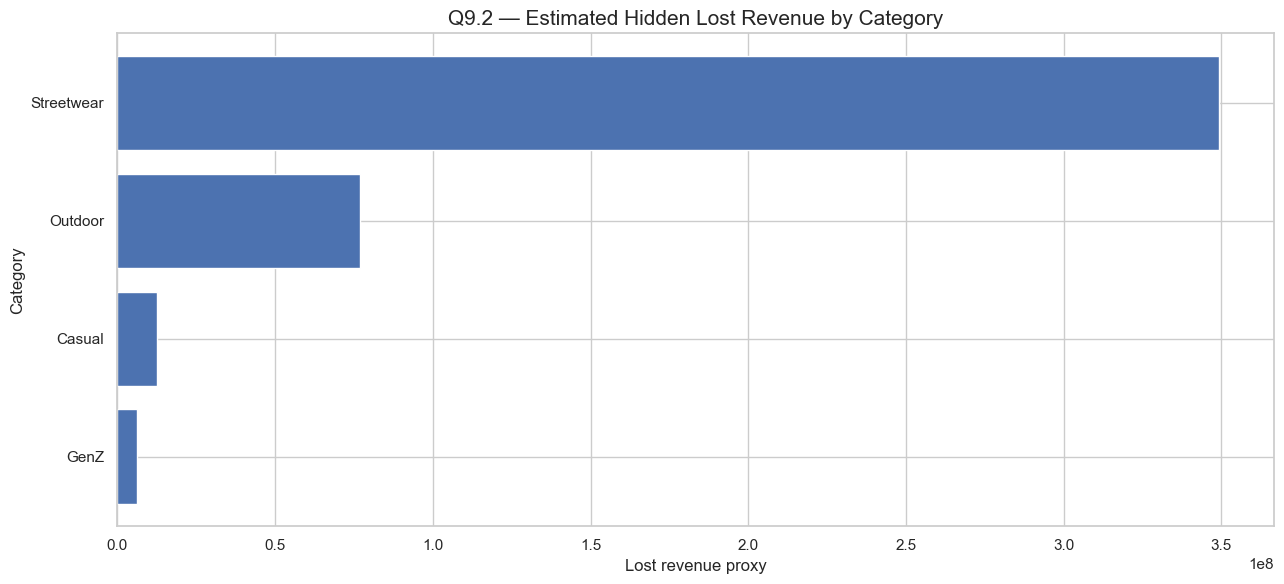

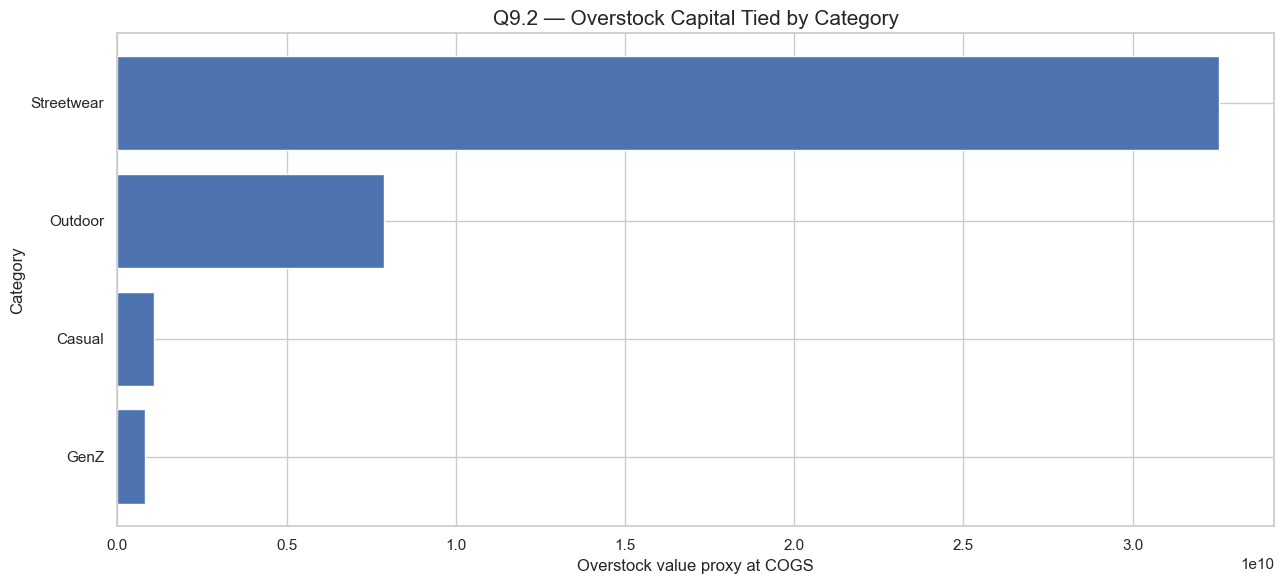

In [6]:
# ============================================================
# Q9.2 DIAGNOSTIC — Category/segment inventory pain points
# ============================================================

cat_inv = df42.groupby("category").agg(
    sku_months=("product_id", "count"),
    stockout_rate=("stockout_flag", "mean"),
    overstock_rate=("overstock_flag", "mean"),
    avg_fill_rate=("fill_rate", "mean"),
    units_sold=("units_sold", "sum"),
    lost_revenue_proxy=("lost_revenue_proxy", "sum"),
    lost_margin_proxy=("lost_margin_proxy", "sum"),
    overstock_value_proxy=("overstock_value_proxy", "sum"),
).reset_index()

cat_inv["stockout_rate_pct"] = cat_inv["stockout_rate"] * 100
cat_inv["overstock_rate_pct"] = cat_inv["overstock_rate"] * 100
cat_inv["lost_revenue_share_pct"] = cat_inv["lost_revenue_proxy"] / cat_inv["lost_revenue_proxy"].sum() * 100
cat_inv["overstock_value_share_pct"] = cat_inv["overstock_value_proxy"] / cat_inv["overstock_value_proxy"].sum() * 100

cat_inv = cat_inv.sort_values("lost_revenue_proxy", ascending=False)
display(cat_inv)

fig, ax = plt.subplots(figsize=(13, 6))
plot_df = cat_inv.sort_values("lost_revenue_proxy", ascending=True)
ax.barh(plot_df["category"], plot_df["lost_revenue_proxy"])
ax.set_title("Q9.2 — Estimated Hidden Lost Revenue by Category")
ax.set_xlabel("Lost revenue proxy")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 6))
plot_df = cat_inv.sort_values("overstock_value_proxy", ascending=True)
ax.barh(plot_df["category"], plot_df["overstock_value_proxy"])
ax.set_title("Q9.2 — Overstock Capital Tied by Category")
ax.set_xlabel("Overstock value proxy at COGS")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()

cat_inv.to_csv(OUTPUT_DIR / "q9_category_inventory_diagnostic.csv", index=False)

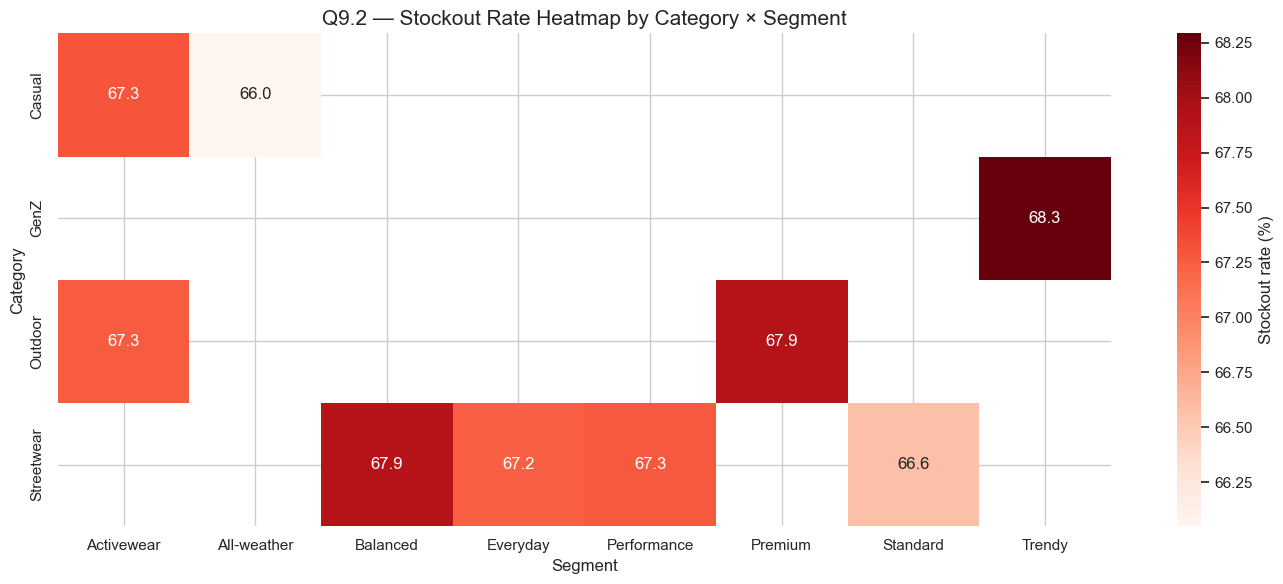

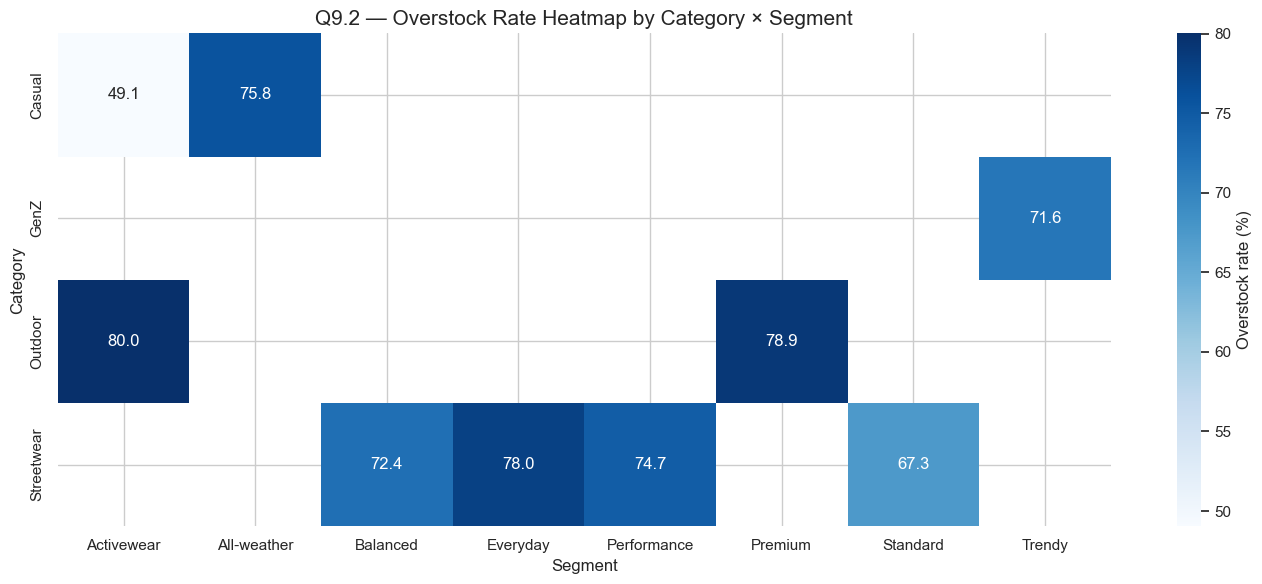

In [7]:
# Segment x category heatmaps
heat_stockout = df42.pivot_table(
    index="category", columns="segment", values="stockout_flag", aggfunc="mean"
) * 100
heat_overstock = df42.pivot_table(
    index="category", columns="segment", values="overstock_flag", aggfunc="mean"
) * 100

plt.figure(figsize=(14, 6))
sns.heatmap(heat_stockout, annot=True, fmt=".1f", cmap="Reds", cbar_kws={"label": "Stockout rate (%)"})
plt.title("Q9.2 — Stockout Rate Heatmap by Category × Segment")
plt.xlabel("Segment")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.heatmap(heat_overstock, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "Overstock rate (%)"})
plt.title("Q9.2 — Overstock Rate Heatmap by Category × Segment")
plt.xlabel("Segment")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [8]:
print("Q9.2 — DIAGNOSTIC INSIGHTS")
top_lost = cat_inv.iloc[0]
top_over = cat_inv.sort_values("overstock_value_proxy", ascending=False).iloc[0]
print(f"- Category contributing most to estimated hidden lost revenue: {top_lost['category']} ({top_lost['lost_revenue_share_pct']:.1f}% of lost revenue proxy).")
print(f"- Category tying most overstock capital: {top_over['category']} ({top_over['overstock_value_share_pct']:.1f}% of overstock value proxy).")
print("- Diagnostic interpretation: nếu một category vừa có stockout cao vừa overstock cao, vấn đề nằm ở allocation/mix planning chứ không chỉ tổng lượng tồn kho.")

Q9.2 — DIAGNOSTIC INSIGHTS
- Category contributing most to estimated hidden lost revenue: Streetwear (78.5% of lost revenue proxy).
- Category tying most overstock capital: Streetwear (76.9% of overstock value proxy).
- Diagnostic interpretation: nếu một category vừa có stockout cao vừa overstock cao, vấn đề nằm ở allocation/mix planning chứ không chỉ tổng lượng tồn kho.


## Q9.3 — Diagnostic mở rộng: Delivery chậm có liên quan rating thấp và return cao không?

,delivery_bucket,orders,avg_delivery_days,return_rate,avg_rating,review_coverage,return_rate_pct
0,Fast (≤P50: 4d),115775,3.001125,0.071576,3.942900,0.202750,7.157593
1,Normal (P50–P75),76667,5.499588,0.072168,3.917163,0.203092,7.216773
2,Slow (P75–P90),38339,7.000000,0.070062,3.937302,0.202649,7.006173
3,Unknown,32197,NaN,0.000000,NaN,0.000000,0.000000


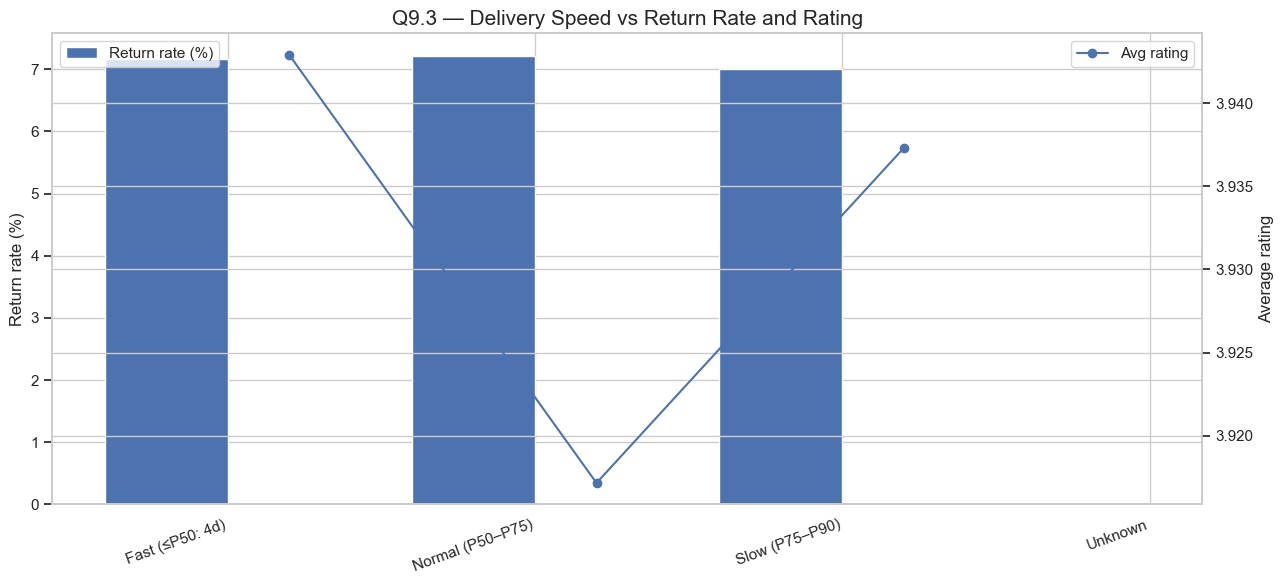

In [9]:
# ============================================================
# Q9.3 DIAGNOSTIC — Delivery experience, rating, return
# ============================================================

delivery_summary = df4.groupby("delivery_bucket").agg(
    orders=("order_id", "nunique"),
    avg_delivery_days=("delivery_days", "mean"),
    return_rate=("return_flag", "mean"),
    avg_rating=("rating", "mean"),
    review_coverage=("review_flag", "mean"),
).reset_index()

# Preserve logical bucket order
bucket_order = [
    f"Fast (≤P50: {p50:.0f}d)",
    f"Normal (P50–P75)",
    f"Slow (P75–P90)",
    f"Very slow (>P90: {p90:.0f}d)",
    "Unknown"
]
delivery_summary["delivery_bucket"] = pd.Categorical(delivery_summary["delivery_bucket"], categories=bucket_order, ordered=True)
delivery_summary = delivery_summary.sort_values("delivery_bucket")
delivery_summary["return_rate_pct"] = delivery_summary["return_rate"] * 100

display(delivery_summary)

fig, ax1 = plt.subplots(figsize=(13, 6))
x = np.arange(len(delivery_summary))
ax1.bar(x - 0.2, delivery_summary["return_rate_pct"], width=0.4, label="Return rate (%)")
ax1.set_ylabel("Return rate (%)")
ax1.set_xticks(x)
ax1.set_xticklabels(delivery_summary["delivery_bucket"], rotation=20, ha="right")

ax2 = ax1.twinx()
ax2.plot(x + 0.2, delivery_summary["avg_rating"], marker="o", label="Avg rating")
ax2.set_ylabel("Average rating")

ax1.set_title("Q9.3 — Delivery Speed vs Return Rate and Rating")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()

delivery_summary.to_csv(OUTPUT_DIR / "q9_delivery_experience_diagnostic.csv", index=False)

In [10]:
valid_summary = delivery_summary[delivery_summary["delivery_bucket"].astype(str) != "Unknown"].copy()
fast_row = valid_summary.iloc[0]
slow_row = valid_summary.iloc[-1]

return_gap = slow_row["return_rate_pct"] - fast_row["return_rate_pct"]
rating_gap = slow_row["avg_rating"] - fast_row["avg_rating"]

print("Q9.3 — DELIVERY DIAGNOSTIC INSIGHTS")
print(f"- Fast bucket return rate: {fast_row['return_rate_pct']:.2f}%; very slow bucket return rate: {slow_row['return_rate_pct']:.2f}%. Gap = {return_gap:+.2f} percentage points.")
print(f"- Fast bucket avg rating: {fast_row['avg_rating']:.2f}; very slow bucket avg rating: {slow_row['avg_rating']:.2f}. Gap = {rating_gap:+.2f} rating points.")
print("- Business meaning: delivery delay should be treated as an experience risk factor, not only a logistics KPI.")

Q9.3 — DELIVERY DIAGNOSTIC INSIGHTS
- Fast bucket return rate: 7.16%; very slow bucket return rate: 7.01%. Gap = -0.15 percentage points.
- Fast bucket avg rating: 3.94; very slow bucket avg rating: 3.94. Gap = -0.01 rating points.
- Business meaning: delivery delay should be treated as an experience risk factor, not only a logistics KPI.


**Cách viết vào report:**  
Nếu nhóm “very slow delivery” có return rate cao hơn và rating thấp hơn nhóm “fast delivery”, doanh nghiệp nên xem logistics là một nguồn tạo return/refund, không chỉ là chi phí vận hành. Điều này hỗ trợ đề xuất tối ưu SLA giao hàng và ưu tiên xử lý nhóm SKU/category nhạy cảm với giao trễ.

## Q9.4 — Predictive: Xây leading indicator cho nguy cơ stockout tháng sau

,risk_decile,sku_months,avg_risk_score,next_month_stockout_rate,avg_fill_rate,avg_days_of_supply,avg_sell_through,next_month_stockout_rate_pct
0,D1,5863,0.002557,0.661436,1.000000,2563.710762,0.024723,66.143612
1,D2,5862,0.010026,0.665302,1.000000,307.163391,0.096673,66.530194
2,D3,5862,0.023646,0.675708,1.000000,108.972364,0.226617,67.570795
3,D4,5862,0.201692,0.673661,0.975471,2354.824343,0.119969,67.366087
4,D5,5863,0.263319,0.661266,0.953962,2248.848985,0.039711,66.126556
5,D6,5862,0.267007,0.668543,0.945943,661.591880,0.059802,66.854316
6,D7,5862,0.271507,0.651996,0.946655,291.474872,0.104455,65.199591
7,D8,5862,0.278027,0.673149,0.946240,160.778182,0.166076,67.314910
8,D9,5862,0.286477,0.677073,0.947841,92.588263,0.249405,67.707267
9,D10,5863,0.318154,0.730002,0.896038,41.522275,0.444876,73.000171


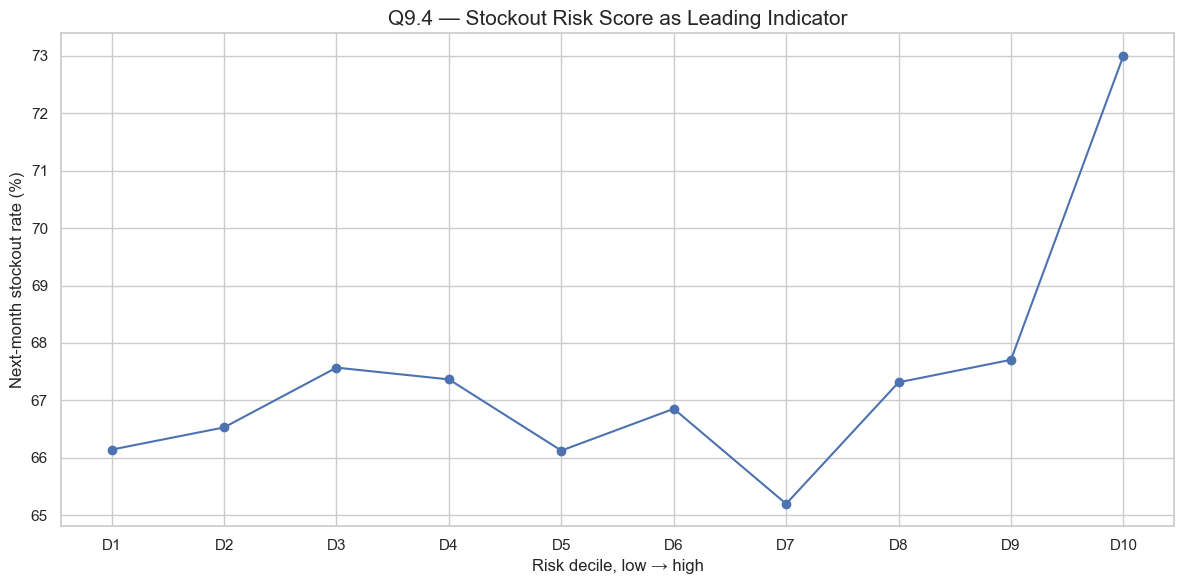

In [11]:
# ============================================================
# Q9.4 PREDICTIVE — Risk score vs next-month stockout
# ============================================================

risk_df = df42.dropna(subset=["next_month_stockout_flag"]).copy()
risk_df["risk_decile"] = pd.qcut(
    risk_df["stockout_risk_score"].rank(method="first"),
    q=10,
    labels=[f"D{i}" for i in range(1, 11)]
)

risk_decile = risk_df.groupby("risk_decile").agg(
    sku_months=("product_id", "count"),
    avg_risk_score=("stockout_risk_score", "mean"),
    next_month_stockout_rate=("next_month_stockout_flag", "mean"),
    avg_fill_rate=("fill_rate", "mean"),
    avg_days_of_supply=("days_of_supply", "mean"),
    avg_sell_through=("sell_through_rate", "mean"),
).reset_index()

risk_decile["next_month_stockout_rate_pct"] = risk_decile["next_month_stockout_rate"] * 100

display(risk_decile)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(risk_decile["risk_decile"], risk_decile["next_month_stockout_rate_pct"], marker="o")
ax.set_title("Q9.4 — Stockout Risk Score as Leading Indicator")
ax.set_xlabel("Risk decile, low → high")
ax.set_ylabel("Next-month stockout rate (%)")
plt.tight_layout()
plt.show()

risk_decile.to_csv(OUTPUT_DIR / "q9_predictive_stockout_risk_decile.csv", index=False)

In [12]:
low_decile = risk_decile.iloc[0]
high_decile = risk_decile.iloc[-1]
lift = high_decile["next_month_stockout_rate"] / max(low_decile["next_month_stockout_rate"], 1e-9)

print("Q9.4 — PREDICTIVE INSIGHTS")
print(f"- Lowest risk decile next-month stockout rate: {low_decile['next_month_stockout_rate_pct']:.2f}%.")
print(f"- Highest risk decile next-month stockout rate: {high_decile['next_month_stockout_rate_pct']:.2f}%.")
print(f"- Risk lift high vs low decile: {lift:.2f}x.")
print("- Business meaning: stockout can be monitored before it happens using reorder flag, fill rate, sell-through and days of supply.")

Q9.4 — PREDICTIVE INSIGHTS
- Lowest risk decile next-month stockout rate: 66.14%.
- Highest risk decile next-month stockout rate: 73.00%.
- Risk lift high vs low decile: 1.10x.
- Business meaning: stockout can be monitored before it happens using reorder flag, fill rate, sell-through and days of supply.


## Q9.5 — Prescriptive: Action matrix cho SKU tồn kho

,recommended_action,sku_count,units_sold,lost_revenue_proxy,lost_margin_proxy,overstock_value_proxy
0,1. Reorder / increase safety stock,107,5273,4.226754e+06,804828.525943,5.177754e+08
1,2. Check allocation / intermittent demand,296,1514,4.319188e+05,91610.023171,2.532511e+08
2,3. Markdown / bundle / liquidation,40,51,0.000000e+00,0.000000,3.838544e+07
3,4. Rebalance stock across channels,69,1850,1.558337e+05,42692.036711,3.462872e+08
4,5. Monitor,28,117,6.915808e+03,1603.480441,1.864681e+05


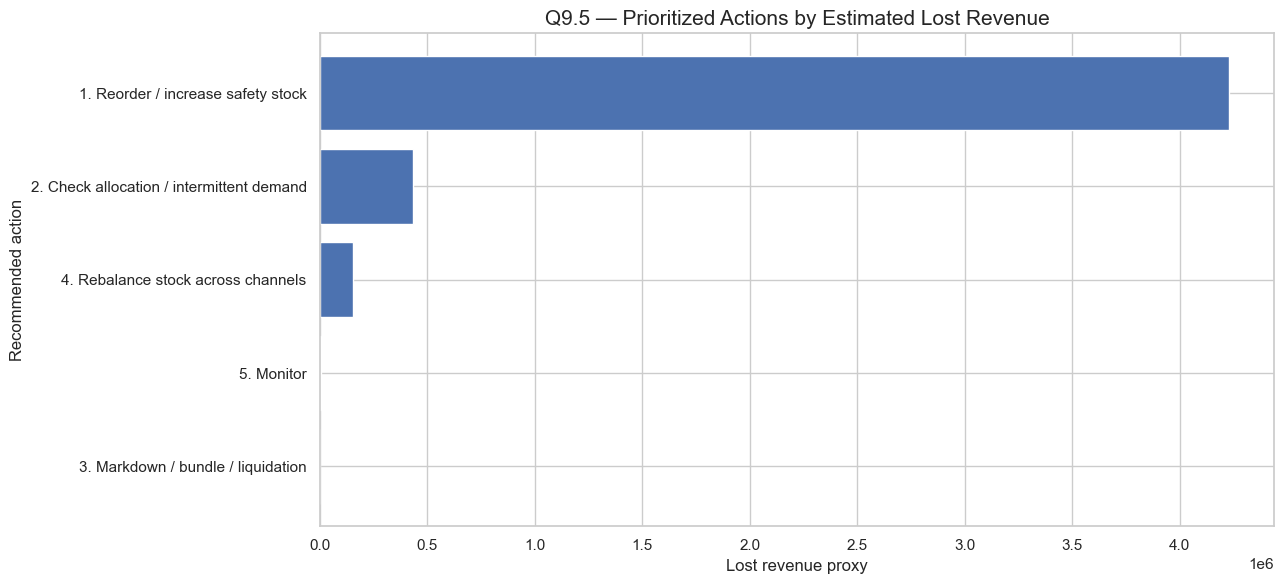

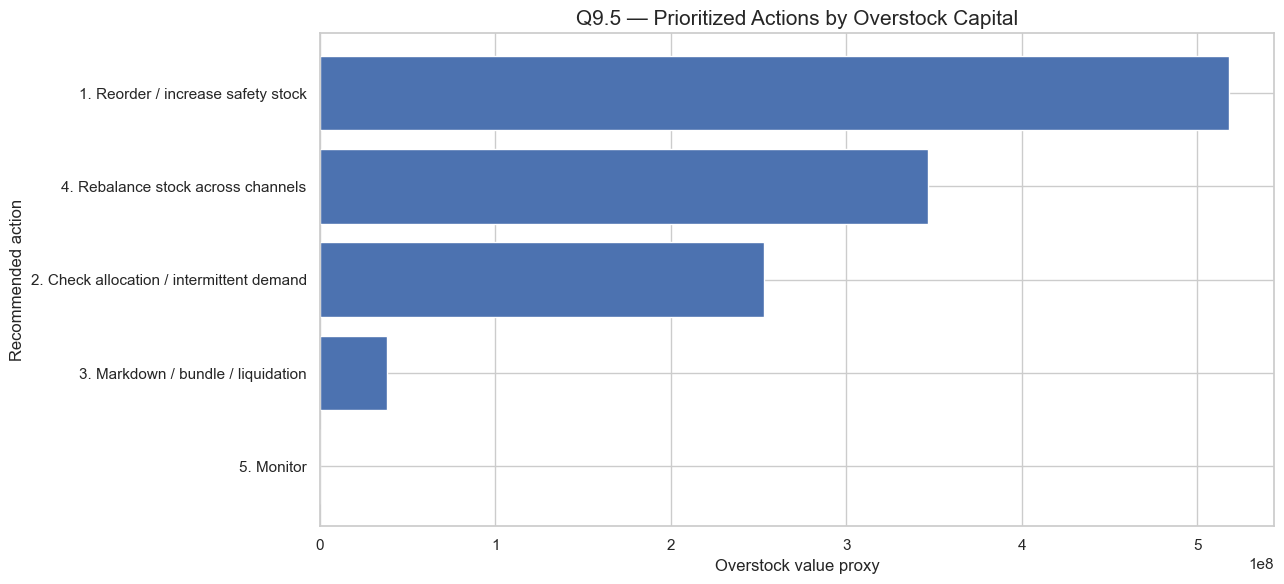

,product_id,product_name,category,segment,size,color,months,units_sold,stock_on_hand,stockout_days,stockout_rate,overstock_rate,reorder_rate,avg_fill_rate,avg_sell_through,lost_revenue_proxy,lost_margin_proxy,overstock_value_proxy,recommended_action
232,1177,MekongFit UE-13,Streetwear,Performance,M,silver,3,148,88,51,1.000000,0.000000,0.0,0.433333,0.626433,699045.688900,34952.284445,0.000000e+00,1. Reorder / increase safety stock
132,720,HanoiStreet RP-08,Outdoor,Activewear,S,red,3,116,59,41,0.666667,0.000000,0.0,0.544467,0.533567,497751.000000,204177.460200,0.000000e+00,1. Reorder / increase safety stock
76,421,SaigonFlex UM-26,Streetwear,Balanced,M,black,3,42,30,24,1.000000,0.000000,0.0,0.733367,0.577133,429716.288195,66219.280011,0.000000e+00,1. Reorder / increase safety stock
131,719,HanoiStreet RP-07,Outdoor,Activewear,XL,yellow,3,116,62,40,0.666667,0.000000,0.0,0.555567,0.524467,415951.920000,91758.993552,0.000000e+00,1. Reorder / increase safety stock
96,505,SaigonFlex UM-10,Streetwear,Balanced,M,purple,3,50,42,17,1.000000,0.000000,0.0,0.811100,0.535267,355460.066727,91282.145135,0.000000e+00,1. Reorder / increase safety stock
69,398,SaigonFlex UM-03,Streetwear,Balanced,L,pink,3,38,28,20,1.000000,0.000000,0.0,0.777800,0.550200,315664.730613,60670.761224,0.000000e+00,1. Reorder / increase safety stock
124,668,SaigonFlex UC-33,Streetwear,Everyday,S,pink,3,41,24,25,1.000000,0.000000,0.0,0.722233,0.631033,296636.317615,72023.297917,0.000000e+00,1. Reorder / increase safety stock
82,449,SaigonFlex UM-54,Streetwear,Balanced,M,yellow,3,326,3276,5,1.000000,1.000000,0.0,0.944433,0.090467,239416.560990,25114.797248,3.695014e+07,1. Reorder / increase safety stock
97,506,SaigonFlex UM-11,Streetwear,Balanced,L,green,3,157,3359,3,0.666667,1.000000,0.0,0.966667,0.044533,66832.733597,4297.344770,4.858132e+07,1. Reorder / increase safety stock
89,470,SaigonFlex UM-75,Streetwear,Balanced,L,red,3,166,652,2,0.333333,0.666667,0.0,0.977767,0.201867,45626.325597,18921.237225,3.276871e+06,4. Rebalance stock across channels


In [13]:
# ============================================================
# Q9.5 PRESCRIPTIVE — SKU action matrix
# ============================================================

# Aggregate recent 3 months to make action recommendations current.
max_month = df42["snapshot_month"].max()
recent_start = max_month - pd.DateOffset(months=2)
recent = df42[df42["snapshot_month"].between(recent_start, max_month)].copy()

sku_action = recent.groupby(["product_id", "product_name", "category", "segment", "size", "color"]).agg(
    months=("snapshot_month", "nunique"),
    units_sold=("units_sold", "sum"),
    stock_on_hand=("stock_on_hand", "sum"),
    stockout_days=("stockout_days", "sum"),
    stockout_rate=("stockout_flag", "mean"),
    overstock_rate=("overstock_flag", "mean"),
    reorder_rate=("reorder_flag", "mean"),
    avg_fill_rate=("fill_rate", "mean"),
    avg_sell_through=("sell_through_rate", "mean"),
    lost_revenue_proxy=("lost_revenue_proxy", "sum"),
    lost_margin_proxy=("lost_margin_proxy", "sum"),
    overstock_value_proxy=("overstock_value_proxy", "sum"),
).reset_index()

# Demand threshold based on recent sales percentile
high_demand_cut = sku_action["units_sold"].quantile(0.75)
low_demand_cut = sku_action["units_sold"].quantile(0.25)

def assign_inventory_action(row):
    if row["stockout_rate"] >= 0.5 and row["units_sold"] >= high_demand_cut:
        return "1. Reorder / increase safety stock"
    if row["stockout_rate"] >= 0.5 and row["units_sold"] < high_demand_cut:
        return "2. Check allocation / intermittent demand"
    if row["overstock_rate"] >= 0.5 and row["units_sold"] <= low_demand_cut:
        return "3. Markdown / bundle / liquidation"
    if row["overstock_rate"] >= 0.5 and row["units_sold"] > low_demand_cut:
        return "4. Rebalance stock across channels"
    return "5. Monitor"

sku_action["recommended_action"] = sku_action.apply(assign_inventory_action, axis=1)

action_summary = sku_action.groupby("recommended_action").agg(
    sku_count=("product_id", "nunique"),
    units_sold=("units_sold", "sum"),
    lost_revenue_proxy=("lost_revenue_proxy", "sum"),
    lost_margin_proxy=("lost_margin_proxy", "sum"),
    overstock_value_proxy=("overstock_value_proxy", "sum"),
).reset_index().sort_values("recommended_action")

display(action_summary)

fig, ax = plt.subplots(figsize=(13, 6))
plot_df = action_summary.sort_values("lost_revenue_proxy", ascending=True)
ax.barh(plot_df["recommended_action"], plot_df["lost_revenue_proxy"])
ax.set_title("Q9.5 — Prioritized Actions by Estimated Lost Revenue")
ax.set_xlabel("Lost revenue proxy")
ax.set_ylabel("Recommended action")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 6))
plot_df = action_summary.sort_values("overstock_value_proxy", ascending=True)
ax.barh(plot_df["recommended_action"], plot_df["overstock_value_proxy"])
ax.set_title("Q9.5 — Prioritized Actions by Overstock Capital")
ax.set_xlabel("Overstock value proxy")
ax.set_ylabel("Recommended action")
plt.tight_layout()
plt.show()

sku_action.sort_values(["recommended_action", "lost_revenue_proxy"], ascending=[True, False]).to_csv(
    OUTPUT_DIR / "q9_sku_prescriptive_action_matrix.csv", index=False
)
action_summary.to_csv(OUTPUT_DIR / "q9_prescriptive_action_summary.csv", index=False)

display(sku_action.sort_values("lost_revenue_proxy", ascending=False).head(15))

In [14]:
print("Q9.5 — PRESCRIPTIVE RECOMMENDATIONS")
for _, r in action_summary.iterrows():
    print(f"- {r['recommended_action']}: {int(r['sku_count'])} SKUs | lost revenue proxy = {r['lost_revenue_proxy']:,.0f} | overstock value proxy = {r['overstock_value_proxy']:,.0f}")

print("\nRecommended operating decisions:")
print("1) For high-demand stockout SKUs: raise safety stock / shorten reorder cycle / prioritize inbound allocation.")
print("2) For low-demand overstock SKUs: markdown, bundle with fast movers, or stop replenishment.")
print("3) For mixed stockout + overstock categories: fix allocation logic by size/color, not only total inventory volume.")
print("4) For slow-delivery buckets: track SLA breach as a return-risk KPI and improve carrier routing/fulfillment priority.")

Q9.5 — PRESCRIPTIVE RECOMMENDATIONS
- 1. Reorder / increase safety stock: 107 SKUs | lost revenue proxy = 4,226,754 | overstock value proxy = 517,775,426
- 2. Check allocation / intermittent demand: 296 SKUs | lost revenue proxy = 431,919 | overstock value proxy = 253,251,075
- 3. Markdown / bundle / liquidation: 40 SKUs | lost revenue proxy = 0 | overstock value proxy = 38,385,441
- 4. Rebalance stock across channels: 69 SKUs | lost revenue proxy = 155,834 | overstock value proxy = 346,287,230
- 5. Monitor: 28 SKUs | lost revenue proxy = 6,916 | overstock value proxy = 186,468

Recommended operating decisions:
1) For high-demand stockout SKUs: raise safety stock / shorten reorder cycle / prioritize inbound allocation.
2) For low-demand overstock SKUs: markdown, bundle with fast movers, or stop replenishment.
3) For mixed stockout + overstock categories: fix allocation logic by size/color, not only total inventory volume.
4) For slow-delivery buckets: track SLA breach as a return-risk 

# Q10 — Tại sao khách trả hàng?

## Logic phân tích

Q10 cần trả lời ở cả cấp độ **reason** và **product attribute**:

- Return cao nhất do lý do nào: `wrong_size`, `defective`, `late_delivery`, v.v.
- Return tập trung ở **category / size / color** nào?
- `wrong_size` thường dẫn tới hành động sizing guide / size recommendation.
- `defective` thường dẫn tới hành động quality control / supplier audit / inspection.
- Cần định lượng tác động bằng refund amount và return quantity để tránh chỉ đếm số đơn.

## Q10.1 — Descriptive: Lý do trả hàng phổ biến nhất là gì?

,return_reason,return_records,return_quantity,refund_amount,record_share_pct,refund_share_pct
4,wrong_size,7436,19971.0,74171036.97,35.029207,34.571664
1,defective,4296,11936.0,43593170.09,20.237422,20.319096
3,not_as_described,3723,10398.0,38320610.84,17.538157,17.861517
0,changed_mind,3613,9958.0,37145242.50,17.019974,17.313670
2,late_delivery,2160,5777.0,21312802.11,10.175240,9.934053


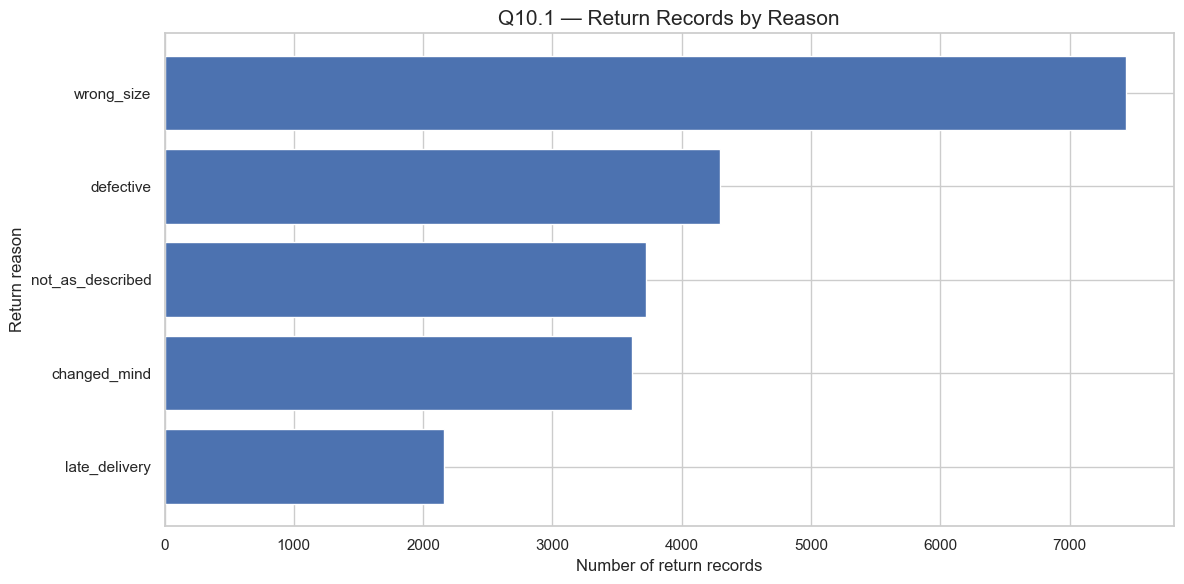

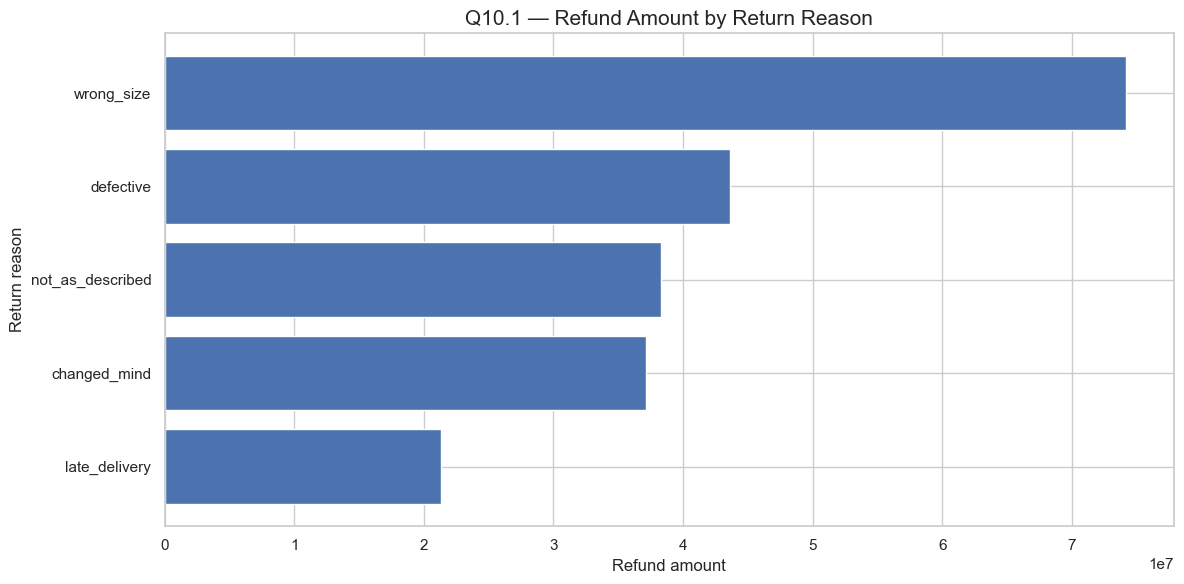

In [15]:
# ============================================================
# Q10.1 DESCRIPTIVE — Return reasons
# ============================================================

return_lines = df5[df5["return_flag"].eq(1)].copy()

reason_summary = return_lines.groupby("return_reason").agg(
    return_records=("return_id", "count"),
    return_quantity=("return_quantity_clean", "sum"),
    refund_amount=("refund_amount_clean", "sum")
).reset_index()

reason_summary["record_share_pct"] = reason_summary["return_records"] / reason_summary["return_records"].sum() * 100
reason_summary["refund_share_pct"] = reason_summary["refund_amount"] / reason_summary["refund_amount"].sum() * 100
reason_summary = reason_summary.sort_values("return_records", ascending=False)

display(reason_summary)

fig, ax = plt.subplots(figsize=(12, 6))
plot_df = reason_summary.sort_values("return_records", ascending=True)
ax.barh(plot_df["return_reason"], plot_df["return_records"])
ax.set_title("Q10.1 — Return Records by Reason")
ax.set_xlabel("Number of return records")
ax.set_ylabel("Return reason")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
plot_df = reason_summary.sort_values("refund_amount", ascending=True)
ax.barh(plot_df["return_reason"], plot_df["refund_amount"])
ax.set_title("Q10.1 — Refund Amount by Return Reason")
ax.set_xlabel("Refund amount")
ax.set_ylabel("Return reason")
plt.tight_layout()
plt.show()

reason_summary.to_csv(OUTPUT_DIR / "q10_return_reason_summary.csv", index=False)

In [16]:
top_reason = reason_summary.iloc[0]
top_refund_reason = reason_summary.sort_values("refund_amount", ascending=False).iloc[0]

print("Q10.1 — DESCRIPTIVE INSIGHTS")
print(f"- Most frequent return reason: {top_reason['return_reason']} ({top_reason['record_share_pct']:.1f}% of return records).")
print(f"- Highest refund-impact reason: {top_refund_reason['return_reason']} ({top_refund_reason['refund_share_pct']:.1f}% of refund amount).")
print("- Business meaning: priority should consider both frequency and refund impact, not frequency alone.")

Q10.1 — DESCRIPTIVE INSIGHTS
- Most frequent return reason: wrong_size (35.0% of return records).
- Highest refund-impact reason: wrong_size (34.6% of refund amount).
- Business meaning: priority should consider both frequency and refund impact, not frequency alone.


## Q10.2 — Descriptive/Diagnostic: Size nào bị trả nhiều nhất?

,size,order_lines,units_ordered,return_records,return_quantity,refund_amount,net_sales,return_record_rate_pct,return_quantity_rate_pct,refund_to_sales_pct
0,L,73609,330999,5399,14646.0,48872093.29,1.290584e+09,7.334701,4.424787,3.786820
1,M,73600,330533,5135,13999.0,45487786.34,1.222973e+09,6.976902,4.235281,3.719444
3,XL,81793,367606,5494,14960.0,67284632.26,1.892625e+09,6.716956,4.069574,3.555095
2,S,78250,352039,5200,14435.0,52898350.62,1.472797e+09,6.645367,4.100398,3.591694


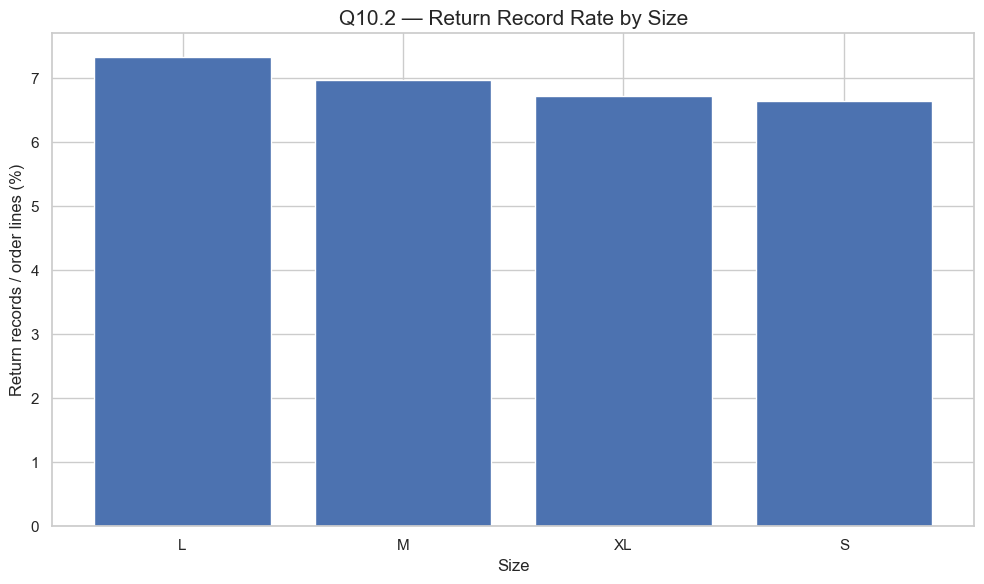

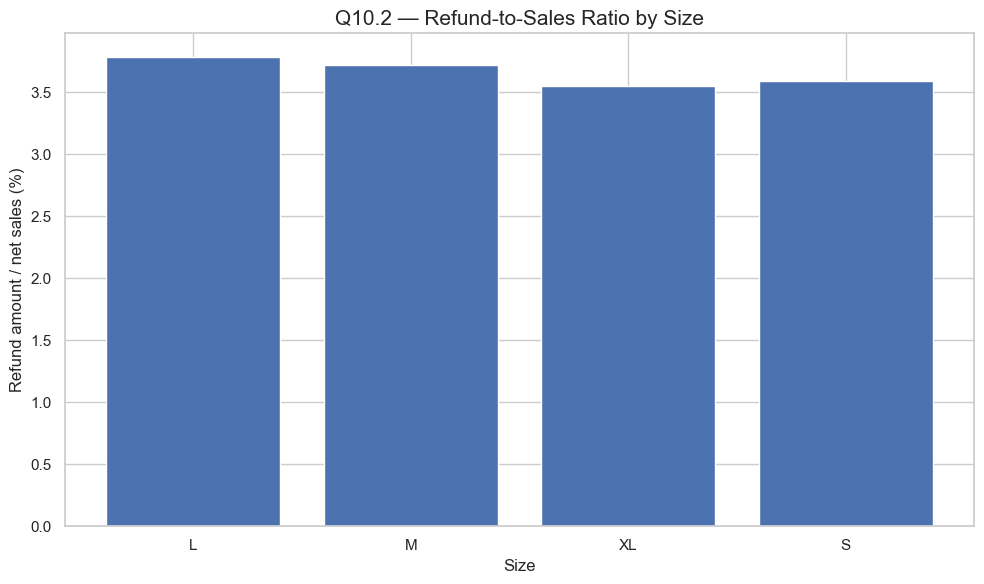

In [17]:
# ============================================================
# Q10.2 SIZE RETURN RATE
# ============================================================

size_summary = df5.groupby("size").agg(
    order_lines=("order_id", "count"),
    units_ordered=("quantity", "sum"),
    return_records=("return_flag", "sum"),
    return_quantity=("return_quantity_clean", "sum"),
    refund_amount=("refund_amount_clean", "sum"),
    net_sales=("net_sales", "sum"),
).reset_index()

size_summary["return_record_rate_pct"] = size_summary["return_records"] / size_summary["order_lines"] * 100
size_summary["return_quantity_rate_pct"] = size_summary["return_quantity"] / size_summary["units_ordered"] * 100
size_summary["refund_to_sales_pct"] = size_summary["refund_amount"] / size_summary["net_sales"] * 100
size_summary = size_summary.sort_values("return_record_rate_pct", ascending=False)

display(size_summary)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(size_summary["size"].astype(str), size_summary["return_record_rate_pct"])
ax.set_title("Q10.2 — Return Record Rate by Size")
ax.set_xlabel("Size")
ax.set_ylabel("Return records / order lines (%)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(size_summary["size"].astype(str), size_summary["refund_to_sales_pct"])
ax.set_title("Q10.2 — Refund-to-Sales Ratio by Size")
ax.set_xlabel("Size")
ax.set_ylabel("Refund amount / net sales (%)")
plt.tight_layout()
plt.show()

size_summary.to_csv(OUTPUT_DIR / "q10_size_return_summary.csv", index=False)

In [18]:
top_size = size_summary.iloc[0]
print("Q10.2 — SIZE INSIGHTS")
print(f"- Size with highest return record rate: {top_size['size']} ({top_size['return_record_rate_pct']:.2f}%).")
print(f"- Its refund-to-sales ratio is {top_size['refund_to_sales_pct']:.2f}%.")
print("- Diagnostic implication: if the dominant reason for this size is wrong_size, sizing guide should be prioritized for this size/category pair.")

Q10.2 — SIZE INSIGHTS
- Size with highest return record rate: L (7.33%).
- Its refund-to-sales ratio is 3.79%.
- Diagnostic implication: if the dominant reason for this size is wrong_size, sizing guide should be prioritized for this size/category pair.


## Q10.3 — Diagnostic: Return rate theo Category × Size và Category × Color

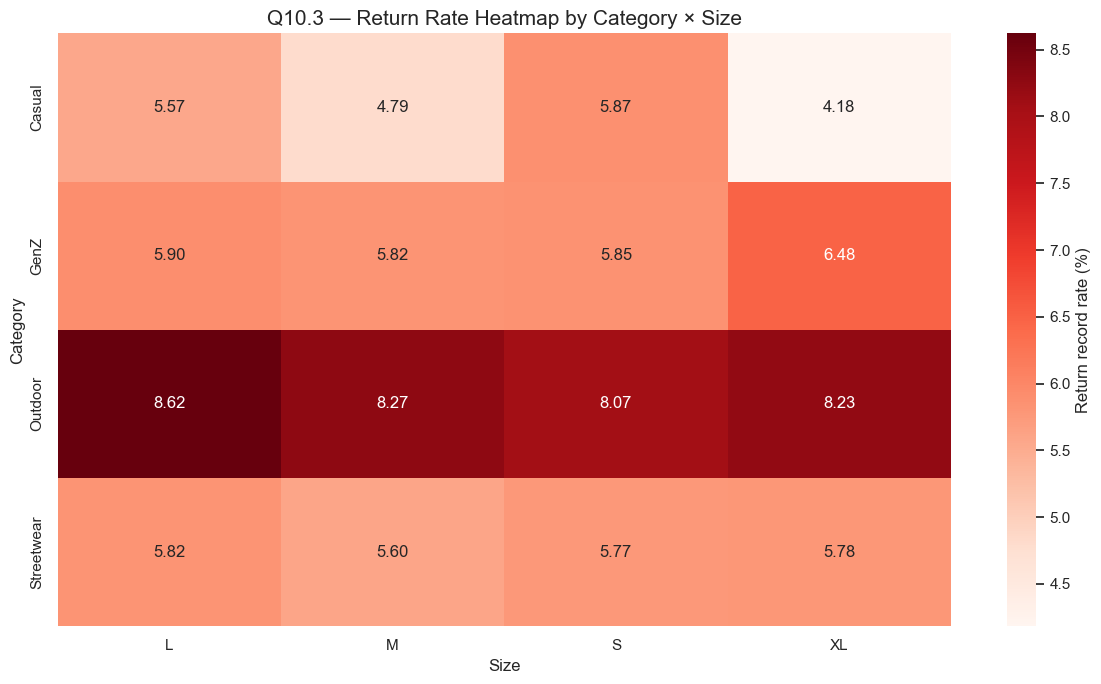

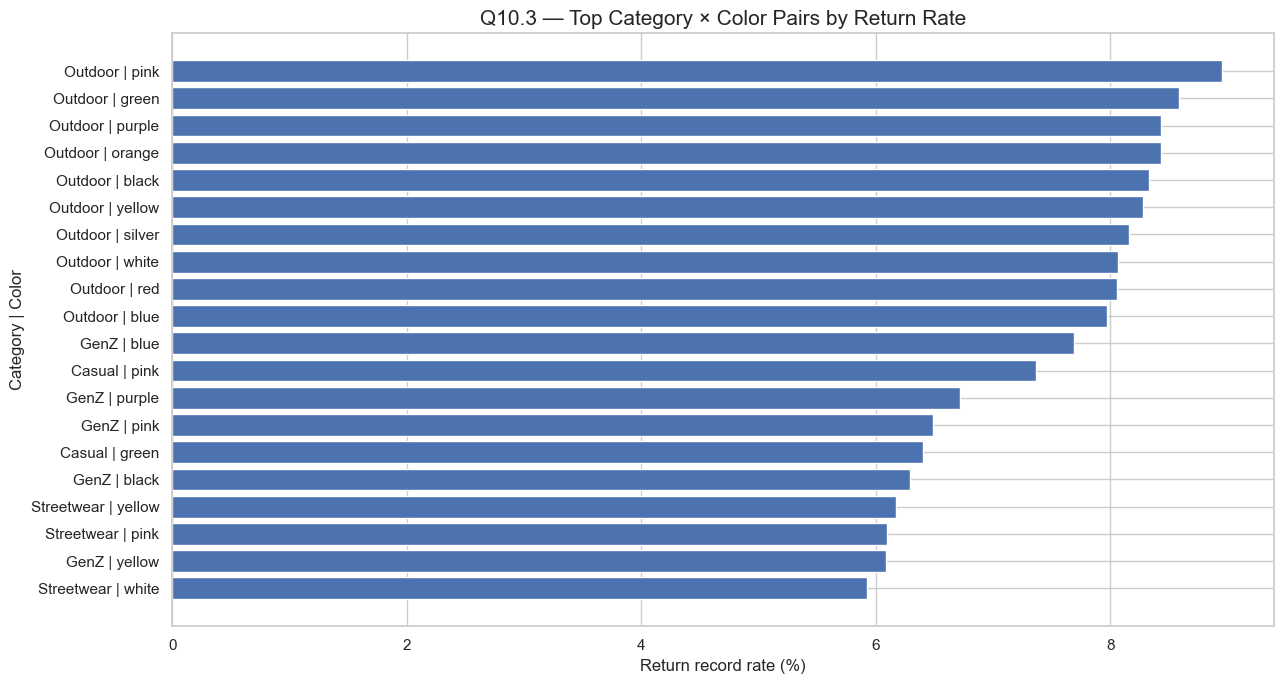

In [19]:
# ============================================================
# Q10.3 DIAGNOSTIC — Category × Size / Color
# ============================================================

cat_size = df5.groupby(["category", "size"]).agg(
    order_lines=("order_id", "count"),
    units_ordered=("quantity", "sum"),
    return_records=("return_flag", "sum"),
    return_quantity=("return_quantity_clean", "sum"),
    refund_amount=("refund_amount_clean", "sum"),
    net_sales=("net_sales", "sum"),
).reset_index()

cat_size["return_record_rate_pct"] = cat_size["return_records"] / cat_size["order_lines"] * 100
cat_size["return_quantity_rate_pct"] = cat_size["return_quantity"] / cat_size["units_ordered"] * 100
cat_size["refund_to_sales_pct"] = cat_size["refund_amount"] / cat_size["net_sales"] * 100

heat_cat_size = cat_size.pivot(index="category", columns="size", values="return_record_rate_pct")

plt.figure(figsize=(12, 7))
sns.heatmap(heat_cat_size, annot=True, fmt=".2f", cmap="Reds", cbar_kws={"label": "Return record rate (%)"})
plt.title("Q10.3 — Return Rate Heatmap by Category × Size")
plt.xlabel("Size")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

cat_color = df5.groupby(["category", "color"]).agg(
    order_lines=("order_id", "count"),
    return_records=("return_flag", "sum"),
    refund_amount=("refund_amount_clean", "sum"),
    net_sales=("net_sales", "sum"),
).reset_index()
cat_color["return_record_rate_pct"] = cat_color["return_records"] / cat_color["order_lines"] * 100
cat_color["refund_to_sales_pct"] = cat_color["refund_amount"] / cat_color["net_sales"] * 100

top_cat_color = cat_color.sort_values("return_record_rate_pct", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(13, 7))
labels = (top_cat_color["category"].astype(str) + " | " + top_cat_color["color"].astype(str)).iloc[::-1]
values = top_cat_color["return_record_rate_pct"].iloc[::-1]
ax.barh(labels, values)
ax.set_title("Q10.3 — Top Category × Color Pairs by Return Rate")
ax.set_xlabel("Return record rate (%)")
ax.set_ylabel("Category | Color")
plt.tight_layout()
plt.show()

cat_size.to_csv(OUTPUT_DIR / "q10_category_size_return_rate.csv", index=False)
cat_color.to_csv(OUTPUT_DIR / "q10_category_color_return_rate.csv", index=False)

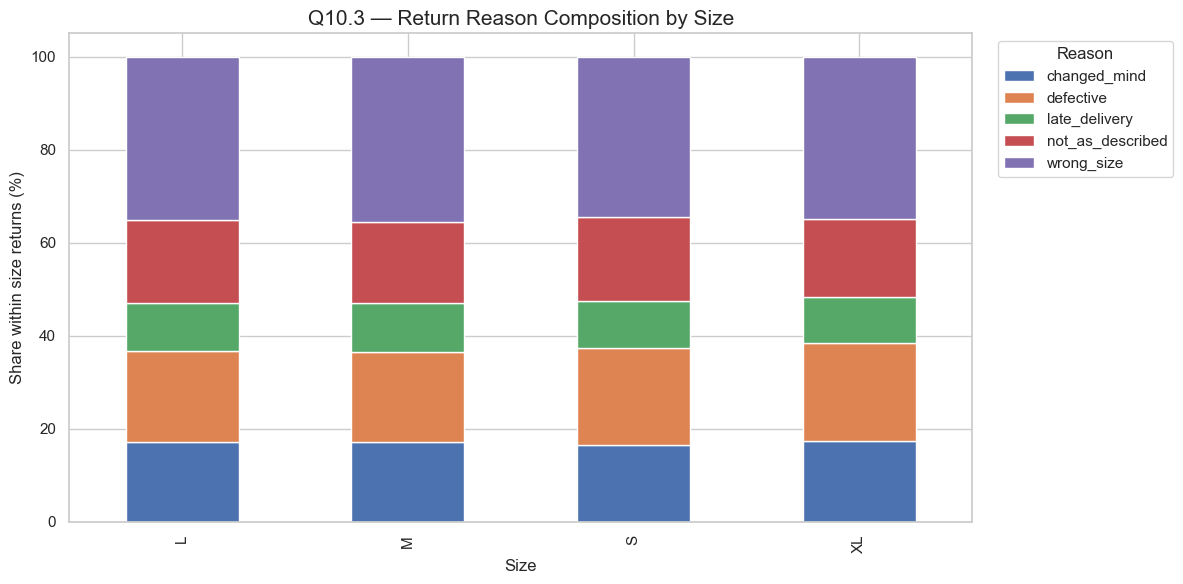

,size,return_reason,return_records,refund_amount,reason_share_within_size_pct
4,L,wrong_size,1901,16198763.55,35.210224
1,L,defective,1052,9393121.29,19.485090
3,L,not_as_described,961,8893623.98,17.799593
0,L,changed_mind,926,8891387.21,17.151324
2,L,late_delivery,559,5495197.26,10.353769
9,M,wrong_size,1824,16009795.99,35.520935
6,M,defective,994,8188060.74,19.357352
8,M,not_as_described,894,8614203.51,17.409932
5,M,changed_mind,879,7779526.18,17.117819
7,M,late_delivery,544,4896199.92,10.593963


,category,return_reason,return_records,refund_amount,reason_share_within_category_pct
4,Casual,wrong_size,131,1342029.28,40.557276
3,Casual,not_as_described,60,546282.07,18.575851
1,Casual,defective,53,497753.83,16.408669
0,Casual,changed_mind,51,460904.47,15.789474
2,Casual,late_delivery,28,265740.74,8.668731
9,GenZ,wrong_size,229,1223069.22,31.071913
6,GenZ,defective,159,775057.08,21.573948
5,GenZ,changed_mind,129,649232.44,17.503392
8,GenZ,not_as_described,129,558802.53,17.503392
7,GenZ,late_delivery,91,434339.38,12.347354


In [20]:
# Reason composition by size/category
reason_by_size = return_lines.groupby(["size", "return_reason"]).agg(
    return_records=("return_id", "count"),
    refund_amount=("refund_amount_clean", "sum")
).reset_index()

reason_by_size["reason_share_within_size_pct"] = reason_by_size.groupby("size")["return_records"].transform(lambda s: s / s.sum() * 100)

reason_pivot_size = reason_by_size.pivot_table(
    index="size", columns="return_reason", values="reason_share_within_size_pct", aggfunc="sum", fill_value=0
)
reason_pivot_size.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Q10.3 — Return Reason Composition by Size")
plt.xlabel("Size")
plt.ylabel("Share within size returns (%)")
plt.legend(title="Reason", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

reason_by_category = return_lines.groupby(["category", "return_reason"]).agg(
    return_records=("return_id", "count"),
    refund_amount=("refund_amount_clean", "sum")
).reset_index()
reason_by_category["reason_share_within_category_pct"] = reason_by_category.groupby("category")["return_records"].transform(lambda s: s / s.sum() * 100)

reason_by_size.to_csv(OUTPUT_DIR / "q10_reason_by_size.csv", index=False)
reason_by_category.to_csv(OUTPUT_DIR / "q10_reason_by_category.csv", index=False)

display(reason_by_size.sort_values(["size", "return_records"], ascending=[True, False]).head(20))
display(reason_by_category.sort_values(["category", "return_records"], ascending=[True, False]).head(20))

In [21]:
top_cat_size = cat_size.sort_values("return_record_rate_pct", ascending=False).iloc[0]
top_cat_color = cat_color.sort_values("return_record_rate_pct", ascending=False).iloc[0]

print("Q10.3 — DIAGNOSTIC INSIGHTS")
print(f"- Highest category-size return rate: {top_cat_size['category']} / {top_cat_size['size']} = {top_cat_size['return_record_rate_pct']:.2f}%.")
print(f"- Highest category-color return rate among pairs: {top_cat_color['category']} / {top_cat_color['color']} = {top_cat_color['return_record_rate_pct']:.2f}%.")
print("- Diagnostic implication: return is not evenly distributed; it concentrates in specific product attribute combinations, so recommendations should be SKU/attribute-specific.")

Q10.3 — DIAGNOSTIC INSIGHTS
- Highest category-size return rate: Outdoor / L = 8.62%.
- Highest category-color return rate among pairs: Outdoor / pink = 8.95%.
- Diagnostic implication: return is not evenly distributed; it concentrates in specific product attribute combinations, so recommendations should be SKU/attribute-specific.


## Q10.4 — Predictive: Product return-risk score

,risk_tier,products,order_lines,return_records,refund_amount,net_sales,avg_return_rate,avg_risk_score,refund_to_sales_pct,actual_return_rate_pct
0,Critical,167,89378,8221,40367009.82,6.894530e+08,0.106188,0.085538,5.854933,9.198013
1,High,166,78401,5617,60707514.01,1.459297e+09,0.071611,0.060043,4.160052,7.164449
2,Low,167,32926,1352,20574548.04,8.954899e+08,0.030609,0.030820,2.297575,4.106177
3,Low evidence,215,1243,89,1186513.66,3.070589e+07,0.077292,0.056299,3.864124,7.160097
4,Medium,166,105304,5949,91707276.98,2.804033e+09,0.055885,0.047230,3.270549,5.649358


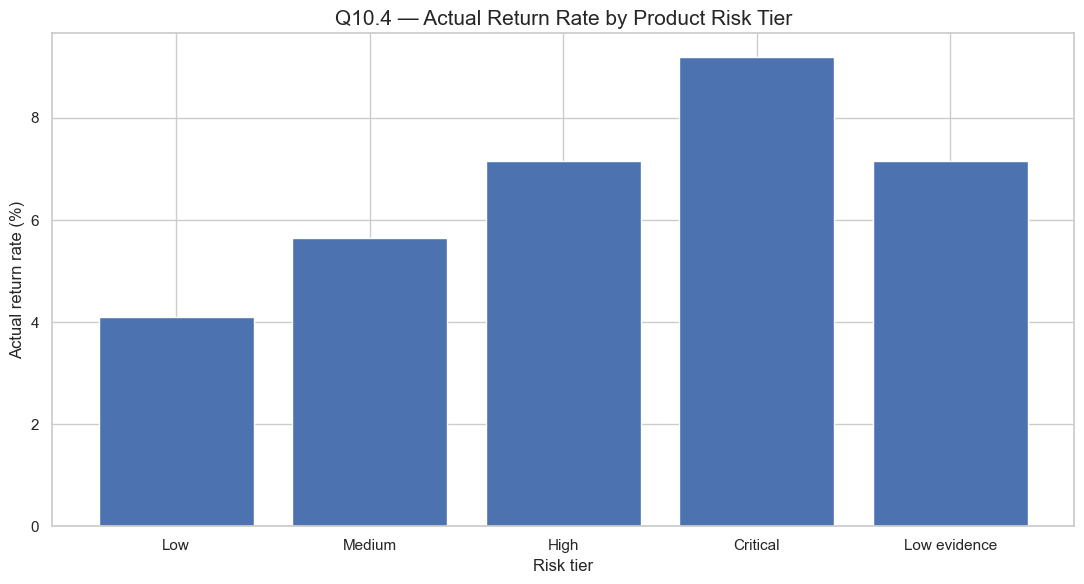

,product_id,product_name,category,segment,size,color,order_lines,units_ordered,return_records,return_quantity,refund_amount,net_sales,return_record_rate,return_quantity_rate,refund_to_sales,smoothed_return_rate,return_risk_score,risk_tier
699,1950,UrbanVN RP-25,Outdoor,Activewear,L,red,2,12,2,11.0,40468.52,47357.76,1.000000,0.916667,0.854528,0.153718,0.291219,Low evidence
700,1951,UrbanVN RP-26,Outdoor,Activewear,XL,black,2,14,2,11.0,40468.52,55414.66,1.000000,0.785714,0.730285,0.153718,0.271576,Low evidence
47,234,LotusWear UR-06,Streetwear,Standard,L,white,2,7,1,6.0,26888.12,36676.48,0.500000,0.857143,0.733116,0.108263,0.255018,Low evidence
480,1309,VietMode RP-01,Outdoor,Activewear,M,yellow,3,11,2,7.0,12089.63,31438.57,0.666667,0.636364,0.384548,0.147034,0.245164,Low evidence
793,2175,PhoenixWear UC-05,Streetwear,Everyday,XL,purple,1,4,1,3.0,16235.37,22774.72,1.000000,0.750000,0.712868,0.113419,0.242040,Low evidence
417,1108,MekongFit RP-54,Outdoor,Activewear,S,pink,1,5,1,3.0,5459.07,9775.20,1.000000,0.600000,0.558461,0.113419,0.219540,Low evidence
385,1042,MekongStyle UC-14,Streetwear,Everyday,L,orange,2,11,1,4.0,56502.37,157687.32,0.500000,0.363636,0.358319,0.108263,0.180992,Low evidence
570,1496,VietMode RP-88,Outdoor,Activewear,S,green,14,52,4,11.0,44316.23,208173.48,0.285714,0.211538,0.212881,0.158288,0.179924,Low evidence
503,1360,VietMode RP-52,Outdoor,Activewear,S,red,3,17,2,4.0,17028.38,80350.09,0.666667,0.235294,0.211927,0.147034,0.176497,Low evidence
849,2340,VietMotion UE-14,Streetwear,Performance,S,red,2,13,1,4.0,21345.06,72421.99,0.500000,0.307692,0.294732,0.108263,0.172600,Low evidence


In [22]:
# ============================================================
# Q10.4 PREDICTIVE — Product return risk score
# ============================================================

product_return = df5.groupby(["product_id_x", "product_name", "category", "segment", "size", "color"]).agg(
    order_lines=("order_id", "count"),
    units_ordered=("quantity", "sum"),
    return_records=("return_flag", "sum"),
    return_quantity=("return_quantity_clean", "sum"),
    refund_amount=("refund_amount_clean", "sum"),
    net_sales=("net_sales", "sum"),
).reset_index().rename(columns={"product_id_x": "product_id"})

product_return["return_record_rate"] = product_return["return_records"] / product_return["order_lines"]
product_return["return_quantity_rate"] = product_return["return_quantity"] / product_return["units_ordered"]
product_return["refund_to_sales"] = product_return["refund_amount"] / product_return["net_sales"].replace(0, np.nan)

# Smooth return rate to avoid overreacting to low-volume products
global_return_rate = df5["return_flag"].mean()
alpha = 20
product_return["smoothed_return_rate"] = (
    product_return["return_records"] + alpha * global_return_rate
) / (product_return["order_lines"] + alpha)

# Risk score combines likelihood and financial impact
product_return["return_risk_score"] = (
    0.60 * product_return["smoothed_return_rate"].fillna(0)
    + 0.25 * product_return["refund_to_sales"].fillna(0).clip(0, product_return["refund_to_sales"].quantile(0.99))
    + 0.15 * product_return["return_quantity_rate"].fillna(0)
)

# Classify risk by quantile, only for products with enough evidence
min_lines = max(10, int(product_return["order_lines"].quantile(0.25)))
eligible = product_return["order_lines"] >= min_lines
product_return["risk_tier"] = "Low evidence"
product_return.loc[eligible, "risk_tier"] = pd.qcut(
    product_return.loc[eligible, "return_risk_score"].rank(method="first"),
    q=4,
    labels=["Low", "Medium", "High", "Critical"]
).astype(str)

risk_tier_summary = product_return.groupby("risk_tier").agg(
    products=("product_id", "nunique"),
    order_lines=("order_lines", "sum"),
    return_records=("return_records", "sum"),
    refund_amount=("refund_amount", "sum"),
    net_sales=("net_sales", "sum"),
    avg_return_rate=("return_record_rate", "mean"),
    avg_risk_score=("return_risk_score", "mean"),
).reset_index()
risk_tier_summary["refund_to_sales_pct"] = risk_tier_summary["refund_amount"] / risk_tier_summary["net_sales"] * 100
risk_tier_summary["actual_return_rate_pct"] = risk_tier_summary["return_records"] / risk_tier_summary["order_lines"] * 100

display(risk_tier_summary)

fig, ax = plt.subplots(figsize=(11, 6))
tier_order = ["Low", "Medium", "High", "Critical", "Low evidence"]
plot_tier = risk_tier_summary.copy()
plot_tier["risk_tier"] = pd.Categorical(plot_tier["risk_tier"], categories=tier_order, ordered=True)
plot_tier = plot_tier.sort_values("risk_tier")
ax.bar(plot_tier["risk_tier"].astype(str), plot_tier["actual_return_rate_pct"])
ax.set_title("Q10.4 — Actual Return Rate by Product Risk Tier")
ax.set_xlabel("Risk tier")
ax.set_ylabel("Actual return rate (%)")
plt.tight_layout()
plt.show()

top_risky_products = product_return.sort_values("return_risk_score", ascending=False).head(20)
display(top_risky_products)

product_return.to_csv(OUTPUT_DIR / "q10_product_return_risk_score.csv", index=False)
top_risky_products.to_csv(OUTPUT_DIR / "q10_top_risky_products.csv", index=False)

In [23]:
critical = risk_tier_summary[risk_tier_summary["risk_tier"].eq("Critical")]
low = risk_tier_summary[risk_tier_summary["risk_tier"].eq("Low")]

print("Q10.4 — PREDICTIVE INSIGHTS")
if len(critical) and len(low):
    c = critical.iloc[0]
    l = low.iloc[0]
    lift = c["actual_return_rate_pct"] / max(l["actual_return_rate_pct"], 1e-9)
    print(f"- Critical product tier return rate: {c['actual_return_rate_pct']:.2f}%.")
    print(f"- Low product tier return rate: {l['actual_return_rate_pct']:.2f}%.")
    print(f"- Return risk lift Critical vs Low: {lift:.2f}x.")
print("- Business meaning: risk score can be used to pre-flag SKUs for sizing review, QC inspection, and product-page improvement before scaling traffic/promotion.")

Q10.4 — PREDICTIVE INSIGHTS
- Critical product tier return rate: 9.20%.
- Low product tier return rate: 4.11%.
- Return risk lift Critical vs Low: 2.24x.
- Business meaning: risk score can be used to pre-flag SKUs for sizing review, QC inspection, and product-page improvement before scaling traffic/promotion.


## Q10.5 — Prescriptive: Sizing guide và quality control tác động bao nhiêu?

,category,size,wrong_size_returns,wrong_size_refund,wrong_size_quantity
15,Streetwear,XL,977,18852253.37,2621.0
14,Streetwear,S,812,13189826.42,2218.0
12,Streetwear,L,609,10627818.61,1592.0
13,Streetwear,M,626,10222829.57,1748.0
8,Outdoor,L,1228,5143974.64,3151.0
9,Outdoor,M,1106,5079726.96,2864.0
10,Outdoor,S,821,4272587.47,2346.0
11,Outdoor,XL,897,4216921.43,2397.0
2,Casual,S,65,657281.62,176.0
5,GenZ,M,60,411926.23,187.0


,category,color,defective_returns,defective_refund,defective_quantity
35,Streetwear,purple,268,5788387.17,764.0
32,Streetwear,green,205,3945288.22,563.0
38,Streetwear,white,223,3600951.34,635.0
30,Streetwear,black,208,3442957.47,570.0
37,Streetwear,silver,174,3370219.51,456.0
39,Streetwear,yellow,140,2691573.45,400.0
33,Streetwear,orange,178,2646632.62,458.0
31,Streetwear,blue,132,2183335.43,362.0
36,Streetwear,red,121,2177079.20,336.0
28,Outdoor,white,328,1688503.21,874.0


,return_reason,reduction_target_pct,current_return_records,current_refund_amount,estimated_refund_savings,estimated_return_records_avoided
0,wrong_size,10,7436,74171036.97,7.417104e+06,743.6
1,defective,10,4296,43593170.09,4.359317e+06,429.6
2,wrong_size,20,7436,74171036.97,1.483421e+07,1487.2
3,defective,20,4296,43593170.09,8.718634e+06,859.2
4,wrong_size,30,7436,74171036.97,2.225131e+07,2230.8
5,defective,30,4296,43593170.09,1.307795e+07,1288.8


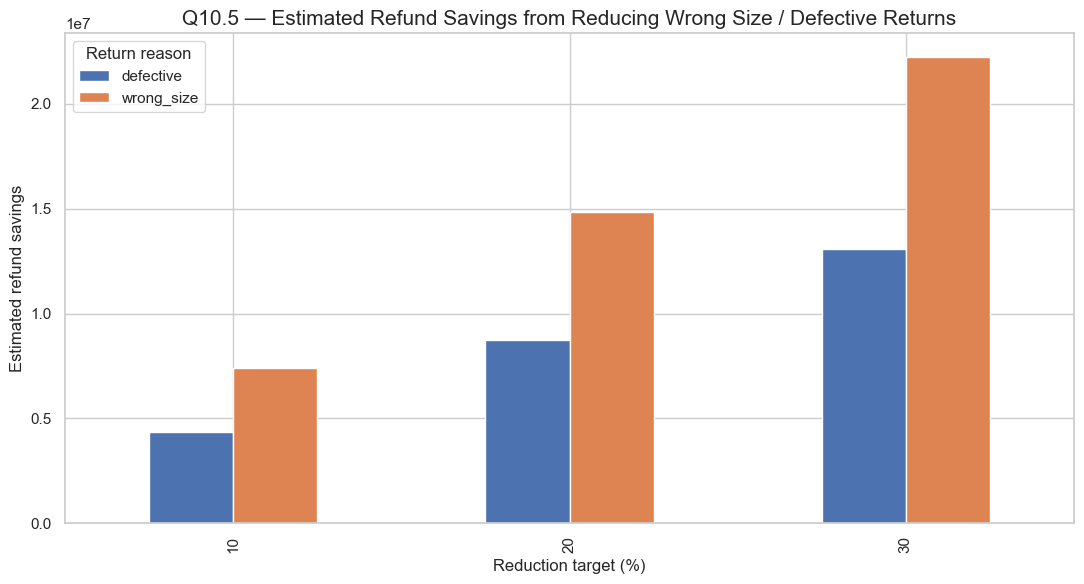

In [24]:
# ============================================================
# Q10.5 PRESCRIPTIVE — Sizing and QC action sizing
# ============================================================

# Action 1: wrong_size reduction by category-size pair
wrong_size = return_lines[return_lines["return_reason"].eq("wrong_size")].copy()
wrong_size_action = wrong_size.groupby(["category", "size"]).agg(
    wrong_size_returns=("return_id", "count"),
    wrong_size_refund=("refund_amount_clean", "sum"),
    wrong_size_quantity=("return_quantity_clean", "sum")
).reset_index().sort_values("wrong_size_refund", ascending=False)

# Action 2: defective reduction by category-color pair
defective = return_lines[return_lines["return_reason"].eq("defective")].copy()
defective_action = defective.groupby(["category", "color"]).agg(
    defective_returns=("return_id", "count"),
    defective_refund=("refund_amount_clean", "sum"),
    defective_quantity=("return_quantity_clean", "sum")
).reset_index().sort_values("defective_refund", ascending=False)

display(wrong_size_action.head(15))
display(defective_action.head(15))

# Scenario analysis: refund savings if reducing selected reasons by 10/20/30%
target_reasons = ["wrong_size", "defective"]
scenario_base = reason_summary[reason_summary["return_reason"].isin(target_reasons)].copy()

scenarios = []
for reduction in [0.10, 0.20, 0.30]:
    for _, r in scenario_base.iterrows():
        scenarios.append({
            "return_reason": r["return_reason"],
            "reduction_target_pct": int(reduction * 100),
            "current_return_records": r["return_records"],
            "current_refund_amount": r["refund_amount"],
            "estimated_refund_savings": r["refund_amount"] * reduction,
            "estimated_return_records_avoided": r["return_records"] * reduction,
        })

scenario_df = pd.DataFrame(scenarios)
display(scenario_df)

scenario_pivot = scenario_df.pivot(index="reduction_target_pct", columns="return_reason", values="estimated_refund_savings")
scenario_pivot.plot(kind="bar", figsize=(11, 6))
plt.title("Q10.5 — Estimated Refund Savings from Reducing Wrong Size / Defective Returns")
plt.xlabel("Reduction target (%)")
plt.ylabel("Estimated refund savings")
plt.legend(title="Return reason")
plt.tight_layout()
plt.show()

wrong_size_action.to_csv(OUTPUT_DIR / "q10_prescriptive_wrong_size_action.csv", index=False)
defective_action.to_csv(OUTPUT_DIR / "q10_prescriptive_defective_action.csv", index=False)
scenario_df.to_csv(OUTPUT_DIR / "q10_prescriptive_scenario_savings.csv", index=False)

In [25]:
print("Q10.5 — PRESCRIPTIVE RECOMMENDATIONS")

if len(wrong_size_action):
    top_ws = wrong_size_action.iloc[0]
    print(f"- Sizing guide priority: {top_ws['category']} / size {top_ws['size']} has the highest wrong_size refund impact = {top_ws['wrong_size_refund']:,.0f}.")
if len(defective_action):
    top_def = defective_action.iloc[0]
    print(f"- QC priority: {top_def['category']} / color {top_def['color']} has the highest defective refund impact = {top_def['defective_refund']:,.0f}.")

print("\nRecommended actions:")
print("1) Wrong_size: add category-specific size chart, fit notes, model reference, and size recommendation for top category-size pairs.")
print("2) Defective: run supplier/batch inspection for top category-color pairs; add pre-shipment QC sampling.")
print("3) Product page: flag high-risk SKUs before promotion; avoid pushing traffic to products with critical return risk.")
print("4) KPI: track return rate, refund-to-sales, wrong_size share, defective share weekly by category-size-color.")

Q10.5 — PRESCRIPTIVE RECOMMENDATIONS
- Sizing guide priority: Streetwear / size XL has the highest wrong_size refund impact = 18,852,253.
- QC priority: Streetwear / color purple has the highest defective refund impact = 5,788,387.

Recommended actions:
1) Wrong_size: add category-specific size chart, fit notes, model reference, and size recommendation for top category-size pairs.
2) Defective: run supplier/batch inspection for top category-color pairs; add pre-shipment QC sampling.
3) Product page: flag high-risk SKUs before promotion; avoid pushing traffic to products with critical return risk.
4) KPI: track return rate, refund-to-sales, wrong_size share, defective share weekly by category-size-color.


## Q9. Inventory & Logistics

**Descriptive:** Tồn kho có vấn đề kép: vừa có stockout gây mất doanh thu tiềm ẩn, vừa có overstock làm giam vốn.  
**Diagnostic:** Stockout/overstock không phân bổ đều mà tập trung theo category/segment/SKU, cho thấy vấn đề chính nằm ở demand planning và allocation, không chỉ tổng lượng tồn kho. Delivery chậm cũng cần được xem như một biến trải nghiệm vì có thể liên quan đến rating thấp và return cao.  
**Predictive:** Có thể xây stockout risk score từ reorder flag, fill rate, sell-through và days of supply để cảnh báo nhóm SKU có nguy cơ stockout tháng sau.  
**Prescriptive:** Doanh nghiệp nên chia SKU thành action matrix: tăng safety stock cho high-demand stockout SKUs, markdown/bundle cho low-demand overstock SKUs, và tái phân bổ hàng cho nhóm có demand tốt nhưng tồn kho lệch kênh/khu vực.

## Q10. Returns

**Descriptive:** Return nên được phân tích theo cả số record, return quantity và refund amount để tránh đánh giá sai mức độ nghiêm trọng.  
**Diagnostic:** Return tập trung theo một số category-size-color combinations; nếu reason chủ đạo là `wrong_size`, vấn đề nằm ở size/fit expectation; nếu reason là `defective`, vấn đề nằm ở QC/supplier.  
**Predictive:** Product return-risk score giúp phát hiện SKU có rủi ro cao trước khi đẩy traffic hoặc promotion.  
**Prescriptive:** Ưu tiên sizing guide cho nhóm category-size có `wrong_size` refund impact cao nhất và QC inspection cho nhóm category-color có `defective` refund impact cao nhất. Scenario analysis 10–30% reduction giúp định lượng refund savings dự kiến.